In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import time
import random

# Read the data
print("Reading CSV files and building original graph...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Create mapping of modules to indices
module_to_index = {module: i for i, module in enumerate(unique_modules)}
index_to_module = {i: module for module, i in module_to_index.items()}
node_to_block = {node: module_to_index[modules[node]] for node in G.nodes()}

# Group nodes by module for more efficient processing
print("Grouping nodes by module...")
nodes_by_module = {module: [] for module in unique_modules}
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate degree sequences
print("Calculating degree sequences...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values()) if in_degrees else 0}, max={max(in_degrees.values()) if in_degrees else 0}")
print(f"Out-degree range: min={min(out_degrees.values()) if out_degrees else 0}, max={max(out_degrees.values()) if out_degrees else 0}")

# Calculate total degrees for each module
print("Calculating total degrees for each module...")
in_degree_by_module = defaultdict(int)
out_degree_by_module = defaultdict(int)

for node, module in modules.items():
    in_degree_by_module[module] += in_degrees[node]
    out_degree_by_module[module] += out_degrees[node]

# Calculate edge counts between modules for module-aware preferential attachment
print("Calculating inter-module edge counts...")
edge_counts = np.zeros((len(unique_modules), len(unique_modules)))

for u, v in G.edges():
    if u in modules and v in modules:
        i = module_to_index[modules[u]]
        j = module_to_index[modules[v]]
        edge_counts[i, j] += 1

print("Edge count matrix calculated")

# Calculate module-to-module connection probabilities
total_edges = edge_counts.sum()
module_connection_probs = edge_counts / total_edges

Starting half-size BCNM generation...
Loading original BCNM model...
Loaded 1011690 edges and 32272 nodes from BCNM files
Creating original BCNM graph...
Adding nodes with metadata...
Adding edges...
Original BCNM graph: 32272 nodes, 1011690 edges
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating node degrees...
Calculating directed clustering coefficients...
Calculating clustering for original BCNM...
Original BCNM average directed clustering coefficient: 0.1193
Calculating connection lengths for original BCNM (sampled)...
Original BCNM average connection length (sampled): 130032.7037

Creating half-size BCNM...
Sampling nodes from each module...
Module 13: original 3168 nodes, sampled 1584 nodes
Module 14: original 3118 nodes, sampled 1559 nodes
Module 8: original 2494 nodes, sampled 1247 nodes
Module 2: original 2431 nodes, sampled 1215 nodes
Module 3: original 2256 nodes, sampled 1128 nodes
Module 11: original 2037 nodes, sampled 1018 

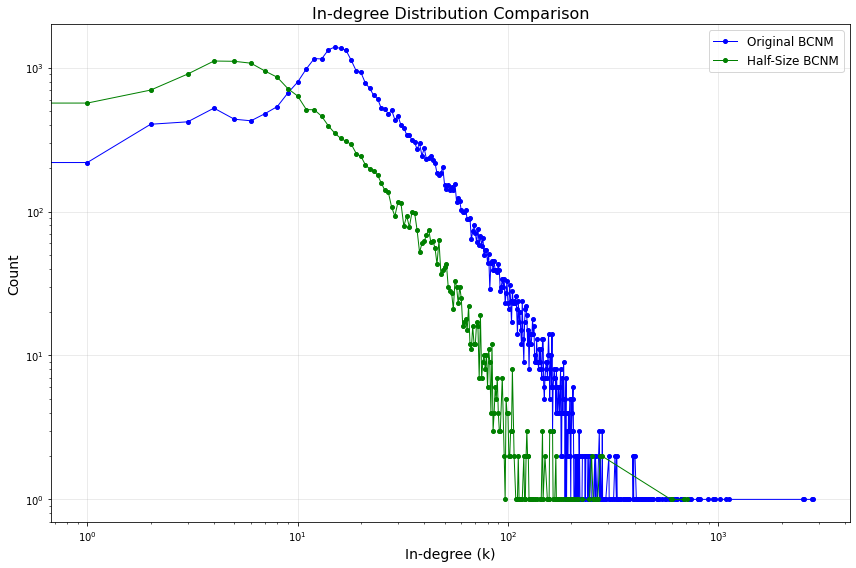

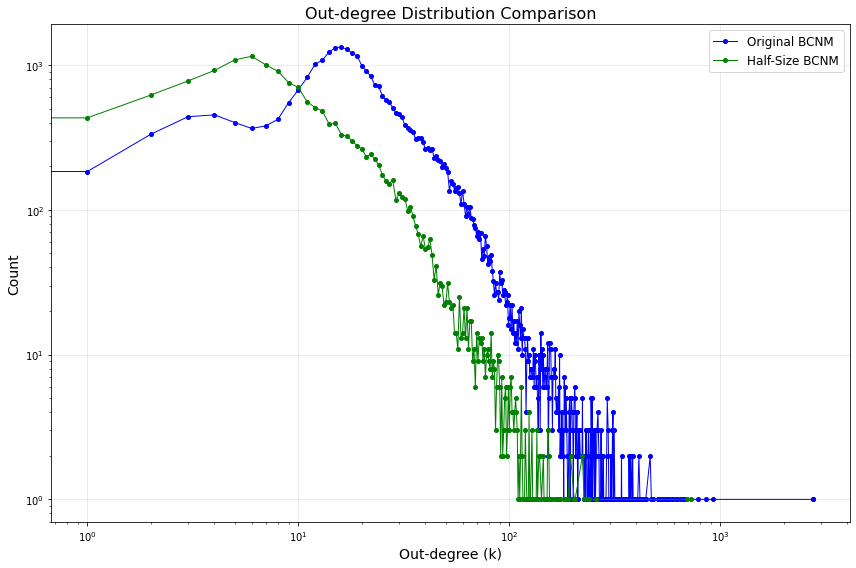

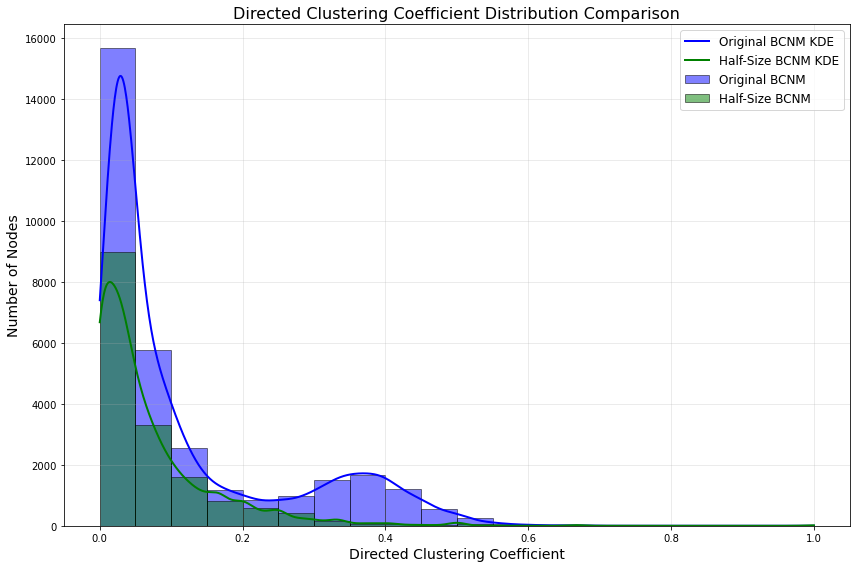

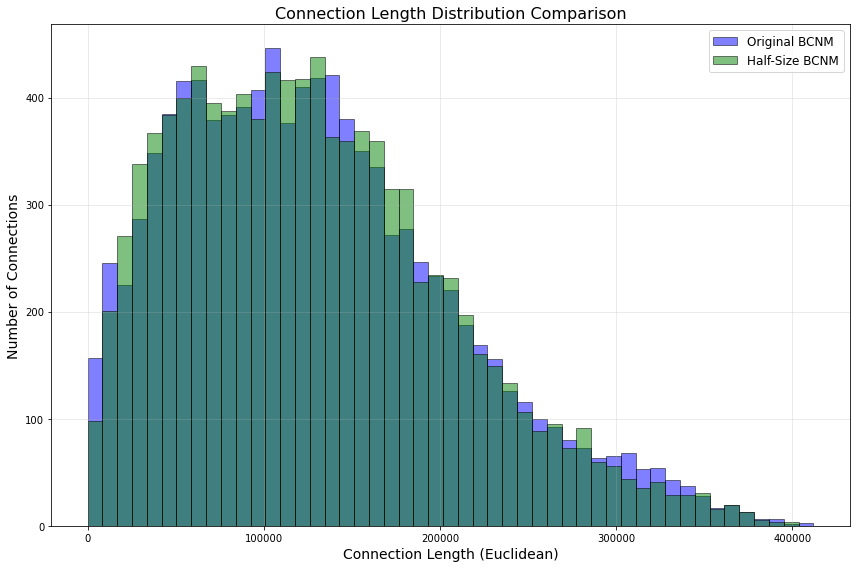

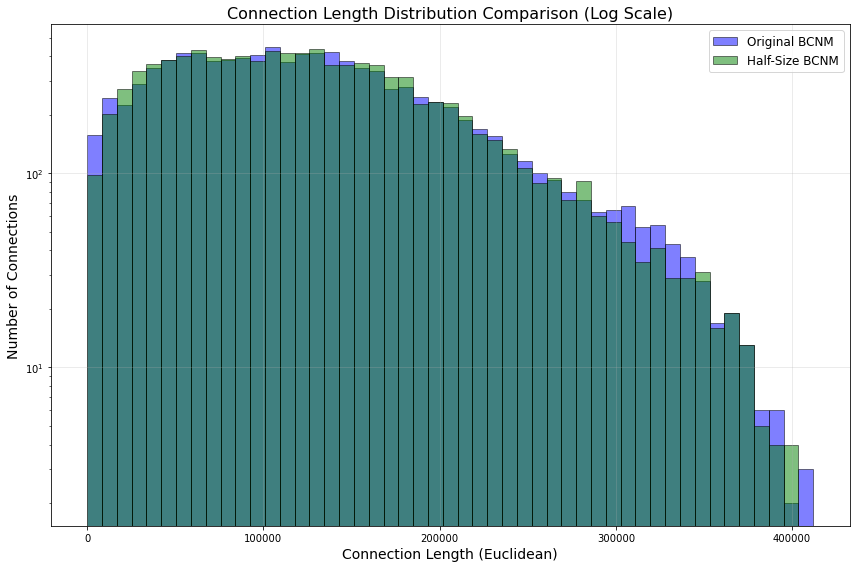

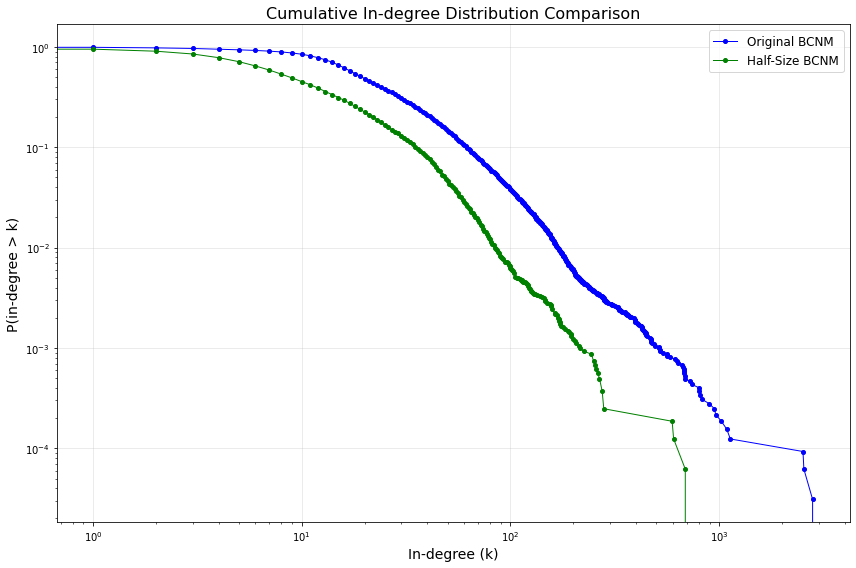

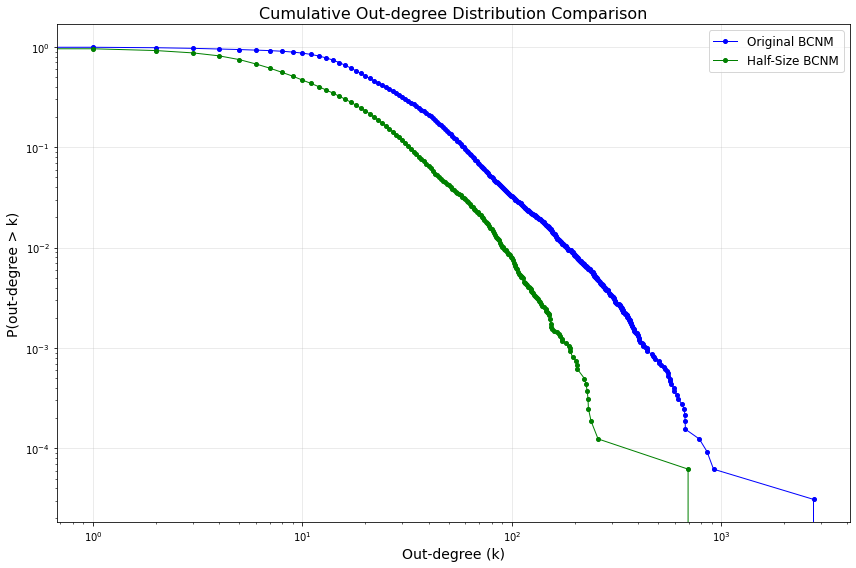

In [8]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting half-size BCNM generation...")
start_time = time.time()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Load the original BCNM model
print("Loading original BCNM model...")
bcnm_edges_df = pd.read_csv("bcnm_edges.csv")
bcnm_metadata_df = pd.read_csv("bcnm_metadata.csv")
print(f"Loaded {len(bcnm_edges_df)} edges and {len(bcnm_metadata_df)} nodes from BCNM files")

# Create the original BCNM graph
print("Creating original BCNM graph...")
bcnm = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in bcnm_metadata_df.iterrows():
    node_id = node_data['node_id']
    bcnm.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
print("Adding edges...")
for _, edge in bcnm_edges_df.iterrows():
    bcnm.add_edge(edge['from'], edge['to'])

print(f"Original BCNM graph: {bcnm.number_of_nodes()} nodes, {bcnm.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(bcnm, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate node degrees
print("Calculating node degrees...")
in_degrees = dict(bcnm.in_degree())
out_degrees = dict(bcnm.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in bcnm.nodes()}

# Calculate directed clustering coefficients
print("Calculating directed clustering coefficients...")
def directed_clustering_coefficient(G):
    clustering = {}
    for node in G.nodes():
        # Get predecessors and successors
        preds = list(G.predecessors(node))
        succs = list(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # Count actual triangles
        actual_triangles = sum(1 for p in preds for s in succs if G.has_edge(p, s))
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

# Calculate clustering for original BCNM
print("Calculating clustering for original BCNM...")
bcnm_clustering = directed_clustering_coefficient(bcnm)
avg_clustering = sum(bcnm_clustering.values()) / len(bcnm_clustering)
print(f"Original BCNM average directed clustering coefficient: {avg_clustering:.4f}")

# Function to calculate Euclidean distance between nodes
def calculate_euclidean_distance(graph, edge):
    u, v = edge
    try:
        u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
        v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
        return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
    except KeyError:
        return None

# Sample edges for distance calculation (to manage memory usage)
print("Calculating connection lengths for original BCNM (sampled)...")
MAX_DISTANCE_SAMPLES = 10000
edges_to_sample = random.sample(list(bcnm.edges()), min(MAX_DISTANCE_SAMPLES, bcnm.number_of_edges()))
bcnm_distances = []
for edge in edges_to_sample:
    distance = calculate_euclidean_distance(bcnm, edge)
    if distance is not None:
        bcnm_distances.append(distance)
avg_distance = np.mean(bcnm_distances)
print(f"Original BCNM average connection length (sampled): {avg_distance:.4f}")

#######################
# Create Half-Size BCNM
#######################
print("\nCreating half-size BCNM...")
half_bcnm = nx.DiGraph()

# Sample half the nodes from each module, maintaining proportions
print("Sampling nodes from each module...")
sampled_nodes = {}
total_sampled = 0

# Calculate module sizes and sort by size to prioritize larger modules
module_sizes = {module: len(nodes) for module, nodes in nodes_by_module.items()}
sorted_modules = sorted(module_sizes.items(), key=lambda x: x[1], reverse=True)

for module, size in sorted_modules:
    # Calculate target size for this module (half the original)
    target_size = max(1, size // 2)
    
    # Sample nodes from this module, prioritizing high-degree nodes
    module_nodes = nodes_by_module[module]
    
    # Sort nodes by degree in descending order
    sorted_nodes = sorted([(node, total_degrees[node]) for node in module_nodes], 
                         key=lambda x: x[1], reverse=True)
    
    # Take top 20% of highest degree nodes to preserve hubs
    hub_count = max(1, int(0.2 * target_size))
    hubs = [node for node, _ in sorted_nodes[:hub_count]]
    
    # Randomly sample the rest
    non_hubs = [node for node, _ in sorted_nodes[hub_count:]]
    remaining_count = target_size - hub_count
    if remaining_count > 0 and non_hubs:
        sampled_non_hubs = random.sample(non_hubs, min(remaining_count, len(non_hubs)))
    else:
        sampled_non_hubs = []
    
    # Combine hubs and sampled non-hubs
    sampled_nodes[module] = hubs + sampled_non_hubs
    total_sampled += len(sampled_nodes[module])
    
    print(f"Module {module}: original {size} nodes, sampled {len(sampled_nodes[module])} nodes")

print(f"Total sampled nodes: {total_sampled} out of {bcnm.number_of_nodes()} original nodes")

# Create flat list of all sampled nodes
all_sampled_nodes = []
for nodes in sampled_nodes.values():
    all_sampled_nodes.extend(nodes)

# Add sampled nodes to the half-size graph with their original attributes
print("Adding sampled nodes to half-size graph...")
for node in all_sampled_nodes:
    half_bcnm.add_node(node, **bcnm.nodes[node])

print(f"Added {half_bcnm.number_of_nodes()} nodes to half-size graph")

# Add edges between sampled nodes
print("Adding edges between sampled nodes...")
edges_added = 0

# Create a set of sampled nodes for faster lookup
sampled_nodes_set = set(all_sampled_nodes)

# For each module, add proportional number of edges
for module, nodes in sampled_nodes.items():
    if len(nodes) <= 1:
        continue  # Skip modules with only one node
    
    # Create subgraph for this module in the original BCNM
    orig_module_nodes = nodes_by_module[module]
    orig_subgraph = bcnm.subgraph(orig_module_nodes)
    orig_edge_count = orig_subgraph.number_of_edges()
    
    # Get original density within this module
    if len(orig_module_nodes) > 1:
        orig_density = orig_edge_count / (len(orig_module_nodes) * (len(orig_module_nodes) - 1))
    else:
        orig_density = 0
    
    # Calculate target number of edges for the half-size module
    # We want to maintain the same density
    target_edge_count = int(orig_density * len(nodes) * (len(nodes) - 1))
    
    print(f"Module {module}: original {orig_edge_count} edges, target {target_edge_count} edges")
    
    # Get existing edges between sampled nodes in this module
    existing_edges = []
    for u in nodes:
        for v in nodes:
            if u != v and bcnm.has_edge(u, v):
                existing_edges.append((u, v))
    
    if len(existing_edges) > target_edge_count:
        # If we have too many edges, sample randomly
        module_edges = random.sample(existing_edges, target_edge_count)
    else:
        # If we have too few edges, keep all existing and add new ones
        module_edges = existing_edges.copy()
        
        # Add more edges randomly until we reach the target
        additional_needed = target_edge_count - len(module_edges)
        attempts = 0
        max_attempts = additional_needed * 10
        
        while len(module_edges) < target_edge_count and attempts < max_attempts:
            u = random.choice(nodes)
            v = random.choice(nodes)
            
            if u != v and (u, v) not in module_edges and not half_bcnm.has_edge(u, v):
                module_edges.append((u, v))
            
            attempts += 1
    
    # Add the edges for this module
    half_bcnm.add_edges_from(module_edges)
    edges_added += len(module_edges)
    
    print(f"Added {len(module_edges)} edges for module {module}")

# Add inter-module edges
print("Adding inter-module edges...")
inter_module_added = 0

# Get original BCNM inter-module edges
orig_inter_module_edges = []
for u, v in bcnm.edges():
    if u in modules and v in modules and modules[u] != modules[v]:
        orig_inter_module_edges.append((u, v))

# Calculate original inter-module density
module_pairs = defaultdict(int)
module_pair_edges = defaultdict(int)

for u, v in orig_inter_module_edges:
    module_u = modules[u]
    module_v = modules[v]
    module_pairs[(module_u, module_v)] += 1

for (module_u, module_v), count in module_pairs.items():
    orig_size_u = len(nodes_by_module[module_u])
    orig_size_v = len(nodes_by_module[module_v])
    
    if orig_size_u > 0 and orig_size_v > 0:
        # Maximum possible edges between modules
        max_edges = orig_size_u * orig_size_v
        # Density
        density = count / max_edges
        module_pair_edges[(module_u, module_v)] = density

# Add inter-module edges to half-size model based on original densities
for (module_u, module_v), density in module_pair_edges.items():
    if module_u not in sampled_nodes or module_v not in sampled_nodes:
        continue
    
    size_u = len(sampled_nodes[module_u])
    size_v = len(sampled_nodes[module_v])
    
    if size_u == 0 or size_v == 0:
        continue
    
    # Target number of edges based on density
    target_edges = int(density * size_u * size_v)
    
    print(f"Inter-module {module_u}-{module_v}: density {density:.6f}, target {target_edges} edges")
    
    # First, add existing edges between sampled nodes
    existing_edges = []
    for u in sampled_nodes[module_u]:
        for v in sampled_nodes[module_v]:
            if bcnm.has_edge(u, v):
                existing_edges.append((u, v))
    
    if len(existing_edges) > target_edges:
        # If we have too many, sample randomly
        module_edges = random.sample(existing_edges, target_edges)
    else:
        # Keep all existing and add new ones if needed
        module_edges = existing_edges.copy()
        
        # Add more edges randomly until we reach the target
        additional_needed = target_edges - len(module_edges)
        attempts = 0
        max_attempts = additional_needed * 10
        
        while len(module_edges) < target_edges and attempts < max_attempts:
            u = random.choice(sampled_nodes[module_u])
            v = random.choice(sampled_nodes[module_v])
            
            if (u, v) not in module_edges and not half_bcnm.has_edge(u, v):
                module_edges.append((u, v))
            
            attempts += 1
    
    # Add the edges
    half_bcnm.add_edges_from(module_edges)
    inter_module_added += len(module_edges)

print(f"Added {inter_module_added} inter-module edges")
print(f"Half-size BCNM: {half_bcnm.number_of_nodes()} nodes, {half_bcnm.number_of_edges()} edges")

##########################
# Calculate network metrics
##########################
print("\nCalculating network metrics...")

# Degree distributions
print("Calculating degree distributions...")
bcnm_in_degrees = list(dict(bcnm.in_degree()).values())
bcnm_out_degrees = list(dict(bcnm.out_degree()).values())
half_in_degrees = list(dict(half_bcnm.in_degree()).values())
half_out_degrees = list(dict(half_bcnm.out_degree()).values())

# Calculate clustering coefficients for half-size network
print("Calculating directed clustering coefficients for half-size BCNM...")
half_clustering = directed_clustering_coefficient(half_bcnm)
half_avg_clustering = sum(half_clustering.values()) / len(half_clustering)

print(f"Original BCNM average directed clustering: {avg_clustering:.4f}")
print(f"Half-size BCNM average directed clustering: {half_avg_clustering:.4f}")

# Calculate connection lengths for half-size network (sampled)
print("Calculating connection lengths for half-size BCNM (sampled)...")

# Half-size network distances
half_edges_to_sample = random.sample(list(half_bcnm.edges()), min(MAX_DISTANCE_SAMPLES, half_bcnm.number_of_edges()))
half_distances = []
for edge in half_edges_to_sample:
    distance = calculate_euclidean_distance(half_bcnm, edge)
    if distance is not None:
        half_distances.append(distance)

half_avg_distance = np.mean(half_distances)

print(f"Original BCNM average connection length: {avg_distance:.4f}")
print(f"Half-size BCNM average connection length: {half_avg_distance:.4f}")

####################
# Generate plot comparisons
####################
print("\nGenerating comparison plots...")

# Plot in-degree distribution comparison
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(bcnm_in_degrees).keys()), 
           [Counter(bcnm_in_degrees)[k] for k in sorted(Counter(bcnm_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(half_in_degrees).keys()), 
           [Counter(half_in_degrees)[k] for k in sorted(Counter(half_in_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='Half-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/half_bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(bcnm_out_degrees).keys()), 
           [Counter(bcnm_out_degrees)[k] for k in sorted(Counter(bcnm_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(half_out_degrees).keys()), 
           [Counter(half_out_degrees)[k] for k in sorted(Counter(half_out_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='Half-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/half_bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Plot clustering coefficient distributions
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

plt.hist(list(bcnm_clustering.values()), bins=bins, alpha=0.5, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(list(half_clustering.values()), bins=bins, alpha=0.5, color='green', 
         edgecolor='black', label='Half-Size BCNM')

# Add kernel density estimation
kde_bcnm = gaussian_kde(list(bcnm_clustering.values()))
kde_half = gaussian_kde(list(half_clustering.values()))
x_vals = np.linspace(0, 1, 1000)

plt.plot(x_vals, kde_bcnm(x_vals) * len(bcnm_clustering) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original BCNM KDE')
plt.plot(x_vals, kde_half(x_vals) * len(half_clustering) * (bins[1] - bins[0]), 
         'g-', linewidth=2, label='Half-Size BCNM KDE')

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/half_bcnm_directed_clustering.png', dpi=600)
print("Saved directed clustering coefficient distribution comparison plot at 600dpi")

# Plot connection length distributions
plt.figure(figsize=(12, 8))
max_distance = max(np.max(bcnm_distances), np.max(half_distances))
bins = np.linspace(0, max_distance, 50)

plt.hist(bcnm_distances, bins=bins, alpha=0.5, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(half_distances, bins=bins, alpha=0.5, color='green', 
         edgecolor='black', label='Half-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/half_bcnm_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
plt.figure(figsize=(12, 8))
plt.hist(bcnm_distances, bins=bins, alpha=0.5, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(half_distances, bins=bins, alpha=0.5, color='green', 
         edgecolor='black', label='Half-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/half_bcnm_connection_length_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot at 600dpi")

# Helper function for cumulative distribution calculation
def compute_cumulative_dist(degrees):
    counter = Counter(degrees)
    sorted_degrees = sorted(counter.items())
    total_nodes = sum(counter.values())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    return x_vals, y_vals

# Calculate cumulative distributions
x_bcnm_in, y_bcnm_in = compute_cumulative_dist(bcnm_in_degrees)
x_half_in, y_half_in = compute_cumulative_dist(half_in_degrees)

# Plot cumulative in-degree distribution
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_in, y_bcnm_in, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_half_in, y_half_in, 'go-', markersize=4, linewidth=1, label='Half-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/half_bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot at 600dpi")

# Calculate out-degree cumulative distributions
x_bcnm_out, y_bcnm_out = compute_cumulative_dist(bcnm_out_degrees)
x_half_out, y_half_out = compute_cumulative_dist(half_out_degrees)

# Plot cumulative out-degree distribution
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_out, y_bcnm_out, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_half_out, y_half_out, 'go-', markersize=4, linewidth=1, label='Half-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/half_bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot at 600dpi")

# Perform statistical comparisons using KS tests
print("\nPerforming statistical comparisons...")

# Sample data for KS tests (to manage memory usage)
def sample_for_ks(data, max_size=1000):
    if len(data) > max_size:
        return random.sample(data, max_size)
    return data

# Create samples
bcnm_in_sample = sample_for_ks(bcnm_in_degrees)
half_in_sample = sample_for_ks(half_in_degrees)
bcnm_out_sample = sample_for_ks(bcnm_out_degrees)
half_out_sample = sample_for_ks(half_out_degrees)
bcnm_clustering_sample = sample_for_ks(list(bcnm_clustering.values()))
half_clustering_sample = sample_for_ks(list(half_clustering.values()))
bcnm_distances_sample = sample_for_ks(bcnm_distances)
half_distances_sample = sample_for_ks(half_distances)

# Perform KS tests
ks_bcnm_half_in = ks_2samp(bcnm_in_sample, half_in_sample)
ks_bcnm_half_out = ks_2samp(bcnm_out_sample, half_out_sample)
ks_bcnm_half_clustering = ks_2samp(bcnm_clustering_sample, half_clustering_sample)
ks_bcnm_half_distances = ks_2samp(bcnm_distances_sample, half_distances_sample)

print("\nDistribution Comparisons (KS Tests):")
print("Original vs Half-Size BCNM:")
print(f"  In-degree distributions: statistic={ks_bcnm_half_in.statistic:.4f}, p-value={ks_bcnm_half_in.pvalue:.4f}")
print(f"  Out-degree distributions: statistic={ks_bcnm_half_out.statistic:.4f}, p-value={ks_bcnm_half_out.pvalue:.4f}")
print(f"  Clustering coefficient distributions: statistic={ks_bcnm_half_clustering.statistic:.4f}, p-value={ks_bcnm_half_clustering.pvalue:.4f}")
print(f"  Connection length distributions: statistic={ks_bcnm_half_distances.statistic:.4f}, p-value={ks_bcnm_half_distances.pvalue:.4f}")

# Generate final comparison summary
print("\nFinal Comparison Summary:")
print(f"Original BCNM: {bcnm.number_of_nodes()} nodes, {bcnm.number_of_edges()} edges")
print(f"Half-size BCNM: {half_bcnm.number_of_nodes()} nodes, {half_bcnm.number_of_edges()} edges")

# Calculate mean degrees
bcnm_mean_in = np.mean(bcnm_in_degrees)
bcnm_mean_out = np.mean(bcnm_out_degrees)
half_mean_in = np.mean(half_in_degrees)
half_mean_out = np.mean(half_out_degrees)

print(f"\nMean degrees:")
print(f"Original BCNM: in={bcnm_mean_in:.2f}, out={bcnm_mean_out:.2f}")
print(f"Half-size BCNM: in={half_mean_in:.2f}, out={half_mean_out:.2f}")

# Calculate node and edge scaling factors
print(f"\nScaling factors:")
print(f"Node ratio: {half_bcnm.number_of_nodes() / bcnm.number_of_nodes():.2f}x")
print(f"Edge ratio: {half_bcnm.number_of_edges() / bcnm.number_of_edges():.2f}x")

# Calculate network density
def calculate_density(G):
    n = G.number_of_nodes()
    if n <= 1:
        return 0
    return G.number_of_edges() / (n * (n - 1))

bcnm_density = calculate_density(bcnm)
half_density = calculate_density(half_bcnm)

print(f"\nNetwork density:")
print(f"Original BCNM: {bcnm_density:.8f}")
print(f"Half-size BCNM: {half_density:.8f}")
print(f"Density ratio (Half/Original): {half_density/bcnm_density:.4f}")

####################
# Export CSV files
####################
print("\nExporting half-size BCNM model to CSV files...")

# Export edges
print("Exporting edges data...")
half_edges = list(half_bcnm.edges())
half_edges_df = pd.DataFrame(half_edges, columns=['from', 'to'])
half_edges_df.to_csv('half_size_bcnm_edges.csv', index=False)

# Export node metadata
print("Exporting node metadata...")
half_nodes = []
for node, data in half_bcnm.nodes(data=True):
    half_nodes.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
half_metadata_df = pd.DataFrame(half_nodes)
half_metadata_df.to_csv('half_size_bcnm_metadata.csv', index=False)

print("CSV exports completed successfully!")

# Print execution time
end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")
print("Half-size BCNM model generation complete!")

Starting BCNM model doubling process...
Loading original BCNM model...
Loaded 1011690 edges and 32272 nodes from BCNM files
Creating original BCNM graph...
Adding nodes with metadata...
Adding edges...
Original BCNM graph: 32272 nodes, 1011690 edges
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating network metrics for original BCNM...
Calculating directed clustering coefficient...
Sampling nodes for clustering coefficient calculation...
Processing 2000 nodes for directed clustering...
  Processed 1000/2000 nodes
Calculated directed clustering for 2000 nodes
Original BCNM average directed clustering coefficient: 0.1161
Calculating connection lengths for original BCNM (sampled)...
Original BCNM average connection length (sampled): 130662.2182
Original BCNM density: 0.00097142

Creating double-size BCNM...
Adding original nodes to double-size graph...
Creating duplicate nodes for double-size graph...
  Created 1000 duplicate nodes
  Created 2

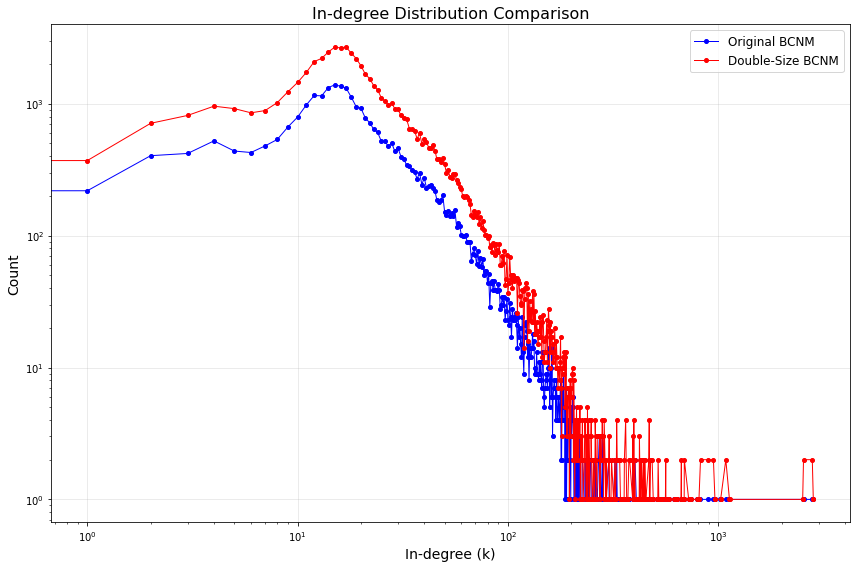

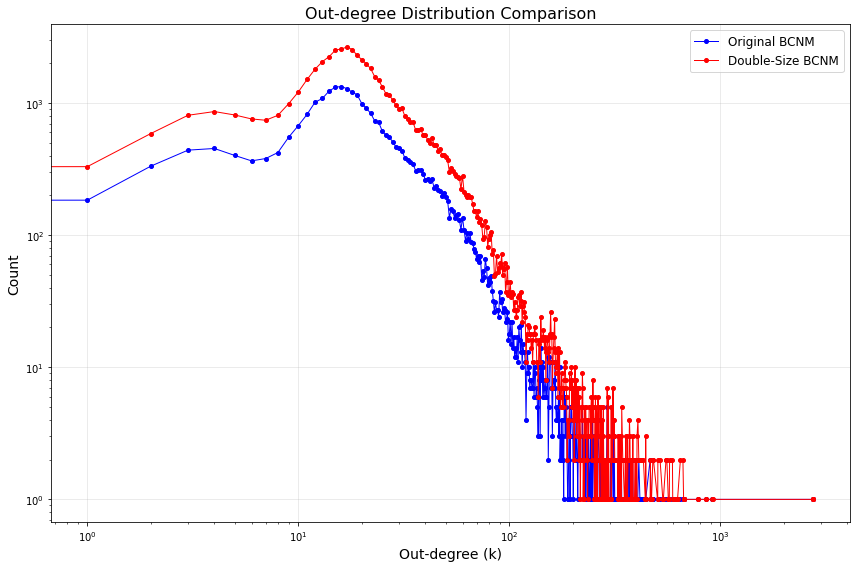

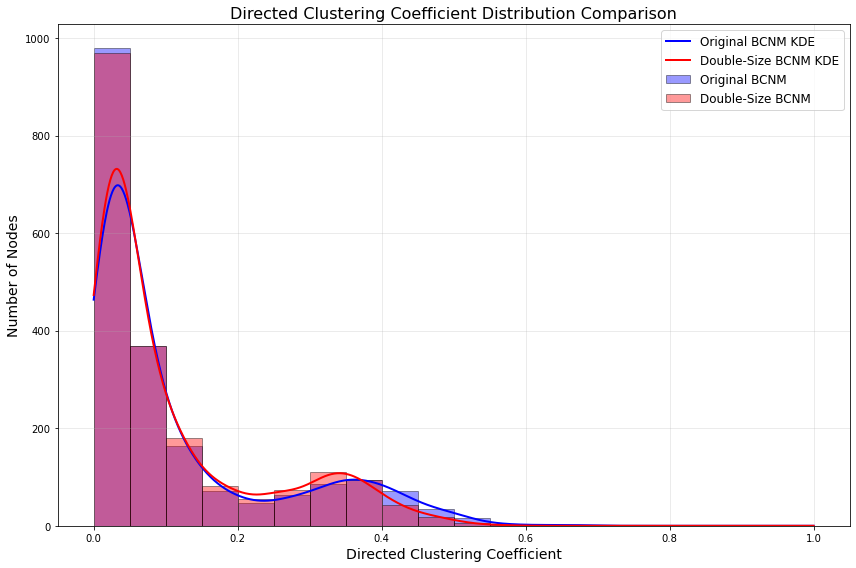

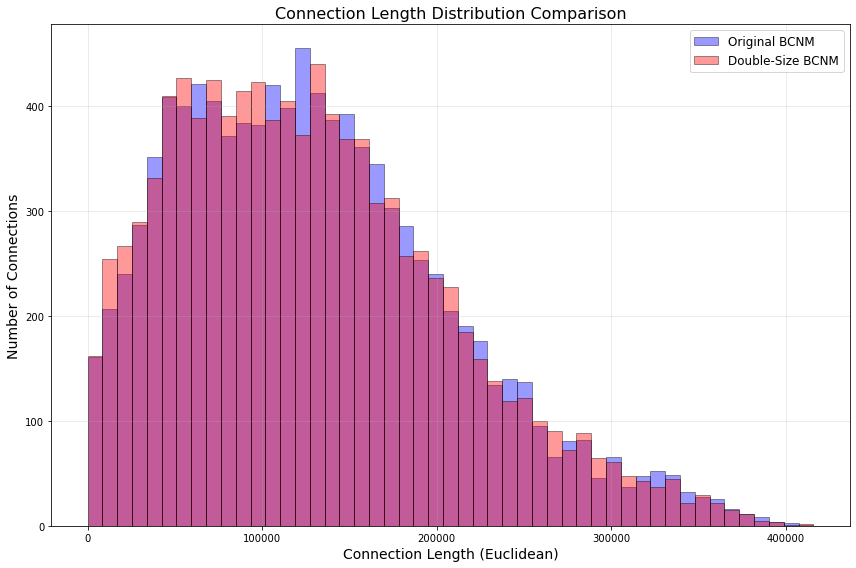

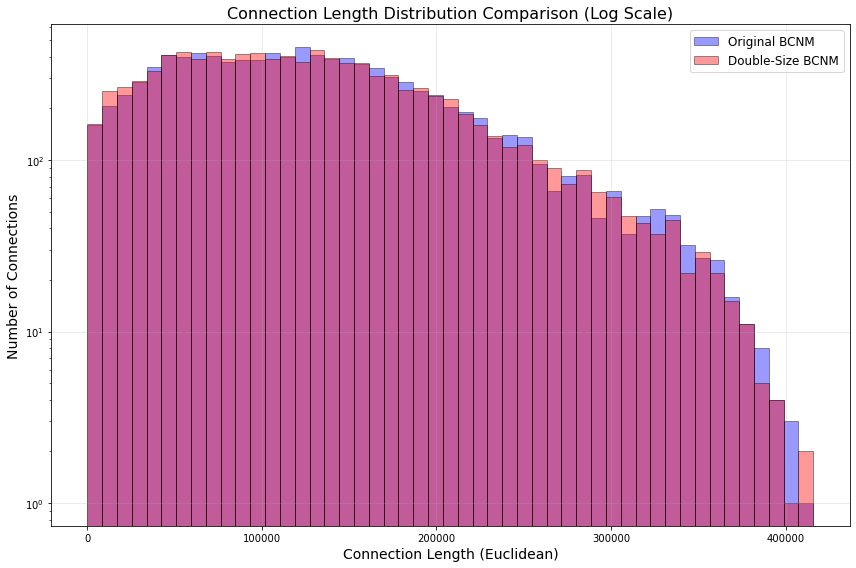

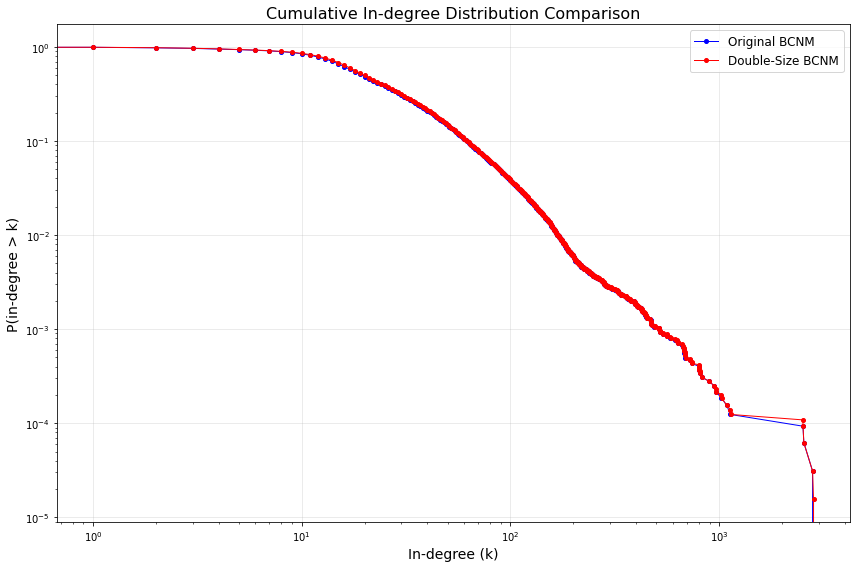

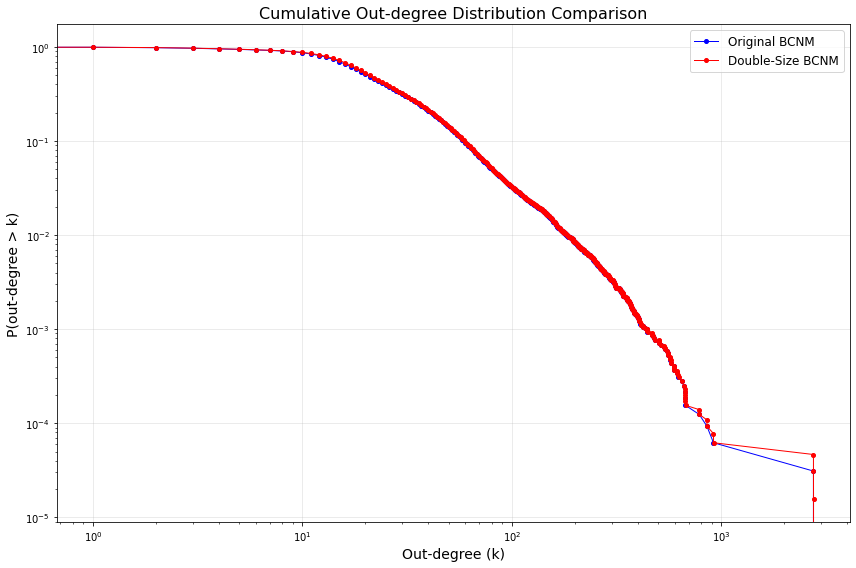

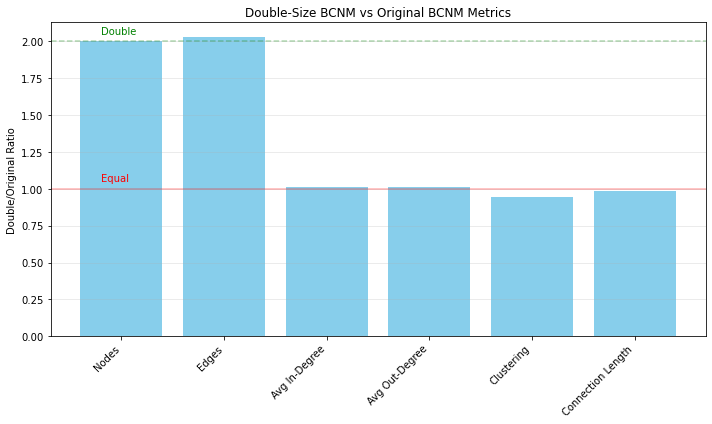

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting BCNM model doubling process...")
start_time = time.time()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created 'plots' directory")

# Load the original BCNM model
print("Loading original BCNM model...")
bcnm_edges_df = pd.read_csv("bcnm_edges.csv")
bcnm_metadata_df = pd.read_csv("bcnm_metadata.csv")
print(f"Loaded {len(bcnm_edges_df)} edges and {len(bcnm_metadata_df)} nodes from BCNM files")

# Create the original BCNM graph
print("Creating original BCNM graph...")
bcnm = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in bcnm_metadata_df.iterrows():
    node_id = node_data['node_id']
    attrs = {}
    for col in bcnm_metadata_df.columns:
        if col != 'node_id':
            attrs[col] = node_data[col]
    bcnm.add_node(node_id, **attrs)

# Add edges
print("Adding edges...")
for _, edge in bcnm_edges_df.iterrows():
    bcnm.add_edge(edge['from'], edge['to'])

print(f"Original BCNM graph: {bcnm.number_of_nodes()} nodes, {bcnm.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(bcnm, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate network metrics for the original BCNM
print("Calculating network metrics for original BCNM...")
in_degrees = dict(bcnm.in_degree())
out_degrees = dict(bcnm.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in bcnm.nodes()}

# Calculate directed clustering coefficient
print("Calculating directed clustering coefficient...")
def directed_clustering_coefficient(G, nodes_to_sample=None):
    """Calculate directed clustering coefficient for nodes in a graph."""
    if nodes_to_sample is None:
        nodes_to_sample = G.nodes()
    
    clustering = {}
    print(f"Processing {len(nodes_to_sample)} nodes for directed clustering...")
    
    for i, node in enumerate(nodes_to_sample):
        if i % 1000 == 0 and i > 0:
            print(f"  Processed {i}/{len(nodes_to_sample)} nodes")
            
        # Get predecessors and successors
        preds = list(G.predecessors(node))
        succs = list(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # For large nodes, sample to improve performance
        if possible_triangles > 1000:
            # Sample predecessor-successor pairs
            sample_size = 1000
            pred_sample = random.sample(preds, min(len(preds), int(np.sqrt(sample_size))))
            succ_sample = random.sample(succs, min(len(succs), int(sample_size / len(pred_sample))))
            
            # Count triangles in sample
            triangles = sum(1 for p in pred_sample for s in succ_sample if G.has_edge(p, s))
            
            # Estimate full count
            actual_triangles = (triangles / (len(pred_sample) * len(succ_sample))) * possible_triangles
        else:
            # Count all triangles
            actual_triangles = sum(1 for p in preds for s in succs if G.has_edge(p, s))
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

# Sample nodes for calculating directed clustering coefficient
print("Sampling nodes for clustering coefficient calculation...")
sample_size = min(2000, bcnm.number_of_nodes())
nodes_to_sample = random.sample(list(bcnm.nodes()), sample_size)
bcnm_clustering = directed_clustering_coefficient(bcnm, nodes_to_sample)

print(f"Calculated directed clustering for {len(bcnm_clustering)} nodes")
avg_clustering = sum(bcnm_clustering.values()) / len(bcnm_clustering)
print(f"Original BCNM average directed clustering coefficient: {avg_clustering:.4f}")

# Function to calculate Euclidean distance between nodes
def calculate_euclidean_distance(graph, edge):
    u, v = edge
    try:
        u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
        v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
        return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
    except KeyError:
        return None

# Sample edges for distance calculation
print("Calculating connection lengths for original BCNM (sampled)...")
MAX_DISTANCE_SAMPLES = 10000
edges_to_sample = random.sample(list(bcnm.edges()), min(MAX_DISTANCE_SAMPLES, bcnm.number_of_edges()))
bcnm_distances = []
for edge in edges_to_sample:
    distance = calculate_euclidean_distance(bcnm, edge)
    if distance is not None:
        bcnm_distances.append(distance)
avg_distance = np.mean(bcnm_distances)
print(f"Original BCNM average connection length (sampled): {avg_distance:.4f}")

# Calculate network density
original_density = bcnm.number_of_edges() / (bcnm.number_of_nodes() * (bcnm.number_of_nodes() - 1))
print(f"Original BCNM density: {original_density:.8f}")

##########################
# Create Double-Size BCNM
##########################
print("\nCreating double-size BCNM...")
double_bcnm = nx.DiGraph()

# Function to generate small random displacement for spatial coordinates
def generate_displacement(scale=0.1):
    return np.random.normal(0, scale, 3)  # For x, y, z coordinates

# First, add all original nodes
print("Adding original nodes to double-size graph...")
for node in bcnm.nodes():
    double_bcnm.add_node(node, **bcnm.nodes[node])

# Then, create duplicate nodes with slight variations to create new nodes
print("Creating duplicate nodes for double-size graph...")
node_to_duplicate = {}  # Mapping from original node to its duplicate

# First duplicate all nodes with metadata
duplicate_count = 0
for node in bcnm.nodes():
    # Generate a new node ID
    new_node = f"dup_{node}"
    
    # Copy attributes with slight spatial variation
    attrs = dict(bcnm.nodes[node])
    if 'x' in attrs and 'y' in attrs and 'z' in attrs:
        # Add small random displacement to coordinates
        displacement = generate_displacement()
        attrs['x'] += displacement[0]
        attrs['y'] += displacement[1]
        attrs['z'] += displacement[2]
    
    # Add the duplicate node
    double_bcnm.add_node(new_node, **attrs)
    node_to_duplicate[node] = new_node
    duplicate_count += 1
    
    if duplicate_count % 1000 == 0:
        print(f"  Created {duplicate_count} duplicate nodes")

print(f"Created {duplicate_count} duplicate nodes")
print(f"Double-size graph has {double_bcnm.number_of_nodes()} nodes")

# Add all edges from the original BCNM
print("Adding original edges to double-size graph...")
double_bcnm.add_edges_from(bcnm.edges())
print(f"Added {bcnm.number_of_edges()} original edges")

# Add edges to connect duplicate nodes
print("Adding edges between duplicate nodes...")
added_edges = 0

# Create edges between duplicates based on original edges
duplicate_edges = []
for u, v in bcnm.edges():
    # Duplicate -> Duplicate (similar to original pattern)
    duplicate_edges.append((node_to_duplicate[u], node_to_duplicate[v]))
    
    # Every 10,000 edges, report progress
    if len(duplicate_edges) % 10000 == 0:
        print(f"  Generated {len(duplicate_edges)} duplicate edges")

double_bcnm.add_edges_from(duplicate_edges)
added_edges += len(duplicate_edges)
print(f"Added {added_edges} duplicate edges")

# Now add cross-connections between original and duplicate nodes by module
print("Creating cross-connections between original and duplicate modules...")
cross_connections = 0

# For each module, add connections between original and duplicate nodes
for module, nodes in nodes_by_module.items():
    original_module_nodes = nodes
    duplicate_module_nodes = [node_to_duplicate[node] for node in nodes]
    
    # Calculate the number of cross-connections to add
    # Use a fraction of the possible connections to maintain overall density
    cross_connection_density = original_density * 0.5  # Use lower density for cross-connections
    possible_connections = len(original_module_nodes) * len(duplicate_module_nodes)
    target_connections = int(cross_connection_density * possible_connections)
    
    print(f"Module {module}: Adding {target_connections} cross-connections")
    
    # Generate random cross-connections
    connections_added = 0
    attempts = 0
    max_attempts = target_connections * 5  # Limit attempts to avoid infinite loops
    
    while connections_added < target_connections and attempts < max_attempts:
        u = random.choice(original_module_nodes)
        v = random.choice(duplicate_module_nodes)
        
        # Add connection in both directions with equal probability
        if random.random() < 0.5:
            if not double_bcnm.has_edge(u, v):
                double_bcnm.add_edge(u, v)
                connections_added += 1
        else:
            if not double_bcnm.has_edge(v, u):
                double_bcnm.add_edge(v, u)
                connections_added += 1
        
        attempts += 1
    
    cross_connections += connections_added
    
    # Report progress every few modules
    if len(original_module_nodes) > 100:
        print(f"  Added {connections_added} cross-connections for module {module}")

print(f"Added a total of {cross_connections} cross-connections between original and duplicate modules")
print(f"Double-size BCNM: {double_bcnm.number_of_nodes()} nodes, {double_bcnm.number_of_edges()} edges")

# Calculate network metrics for the double-size BCNM
print("\nCalculating network metrics for double-size BCNM...")
double_in_degrees = dict(double_bcnm.in_degree())
double_out_degrees = dict(double_bcnm.out_degree())
double_total_degrees = {node: double_in_degrees[node] + double_out_degrees[node] for node in double_bcnm.nodes()}

# Sample nodes for calculating directed clustering coefficient
print("Sampling nodes for double-size BCNM clustering coefficient calculation...")
double_sample_size = min(2000, double_bcnm.number_of_nodes())
double_nodes_to_sample = random.sample(list(double_bcnm.nodes()), double_sample_size)
double_clustering = directed_clustering_coefficient(double_bcnm, double_nodes_to_sample)

print(f"Calculated directed clustering for {len(double_clustering)} nodes in double-size BCNM")
double_avg_clustering = sum(double_clustering.values()) / len(double_clustering)
print(f"Double-size BCNM average directed clustering coefficient: {double_avg_clustering:.4f}")

# Sample edges for distance calculation
print("Calculating connection lengths for double-size BCNM (sampled)...")
double_edges_to_sample = random.sample(list(double_bcnm.edges()), min(MAX_DISTANCE_SAMPLES, double_bcnm.number_of_edges()))
double_distances = []
for edge in double_edges_to_sample:
    distance = calculate_euclidean_distance(double_bcnm, edge)
    if distance is not None:
        double_distances.append(distance)
double_avg_distance = np.mean(double_distances)
print(f"Double-size BCNM average connection length (sampled): {double_avg_distance:.4f}")

# Calculate network density
double_density = double_bcnm.number_of_edges() / (double_bcnm.number_of_nodes() * (double_bcnm.number_of_nodes() - 1))
print(f"Double-size BCNM density: {double_density:.8f}")
print(f"Density ratio (Double/Original): {double_density/original_density:.4f}")

####################
# Generate plots comparing the original and double-size models
####################
print("\nGenerating comparison plots...")

# Plot in-degree distribution comparison
print("Plotting in-degree distribution...")
plt.figure(figsize=(12, 8))
original_in_degrees = list(dict(bcnm.in_degree()).values())
double_in_degrees = list(dict(double_bcnm.in_degree()).values())

plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(double_in_degrees).keys()), 
           [Counter(double_in_degrees)[k] for k in sorted(Counter(double_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
print("Plotting out-degree distribution...")
plt.figure(figsize=(12, 8))
original_out_degrees = list(dict(bcnm.out_degree()).values())
double_out_degrees = list(dict(double_bcnm.out_degree()).values())

plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(double_out_degrees).keys()), 
           [Counter(double_out_degrees)[k] for k in sorted(Counter(double_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

plt.hist(list(bcnm_clustering.values()), bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(list(double_clustering.values()), bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size BCNM')

# Add kernel density estimation
kde_bcnm = gaussian_kde(list(bcnm_clustering.values()))
kde_double = gaussian_kde(list(double_clustering.values()))
x_vals = np.linspace(0, 1, 1000)

plt.plot(x_vals, kde_bcnm(x_vals) * len(bcnm_clustering) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original BCNM KDE')
plt.plot(x_vals, kde_double(x_vals) * len(double_clustering) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='Double-Size BCNM KDE')

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_clustering_coefficient.png', dpi=600)
print("Saved clustering coefficient distribution comparison plot at 600dpi")

# Plot connection length distributions
print("Plotting connection length distributions...")
plt.figure(figsize=(12, 8))
max_distance = max(np.max(bcnm_distances), np.max(double_distances))
bins = np.linspace(0, max_distance, 50)

plt.hist(bcnm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(double_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
print("Plotting connection length distributions with log scale...")
plt.figure(figsize=(12, 8))
plt.hist(bcnm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(double_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_connection_length_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot at 600dpi")

# Helper function for cumulative distribution calculation
def compute_cumulative_dist(degrees):
    counter = Counter(degrees)
    sorted_degrees = sorted(counter.items())
    total_nodes = sum(counter.values())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    return x_vals, y_vals

# Calculate cumulative distributions
print("Calculating cumulative degree distributions...")
x_bcnm_in, y_bcnm_in = compute_cumulative_dist(original_in_degrees)
x_double_in, y_double_in = compute_cumulative_dist(double_in_degrees)

# Plot cumulative in-degree distribution
print("Plotting cumulative in-degree distribution...")
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_in, y_bcnm_in, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_double_in, y_double_in, 'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot at 600dpi")

# Calculate out-degree cumulative distributions
x_bcnm_out, y_bcnm_out = compute_cumulative_dist(original_out_degrees)
x_double_out, y_double_out = compute_cumulative_dist(double_out_degrees)

# Plot cumulative out-degree distribution
print("Plotting cumulative out-degree distribution...")
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_out, y_bcnm_out, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_double_out, y_double_out, 'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot at 600dpi")

# Perform statistical tests to compare distributions
print("\nPerforming statistical comparison of distributions...")
# Sample distributions for statistical comparison
def sample_for_stats(data, max_samples=1000):
    if len(data) > max_samples:
        return random.sample(data, max_samples)
    return data

# Get samples for testing
original_in_sample = sample_for_stats(original_in_degrees)
double_in_sample = sample_for_stats(double_in_degrees)
original_out_sample = sample_for_stats(original_out_degrees)
double_out_sample = sample_for_stats(double_out_degrees)
original_cc_sample = sample_for_stats(list(bcnm_clustering.values()))
double_cc_sample = sample_for_stats(list(double_clustering.values()))
original_dist_sample = sample_for_stats(bcnm_distances)
double_dist_sample = sample_for_stats(double_distances)

# Perform KS tests
ks_in_degree = ks_2samp(original_in_sample, double_in_sample)
ks_out_degree = ks_2samp(original_out_sample, double_out_sample)
ks_clustering = ks_2samp(original_cc_sample, double_cc_sample)
ks_distances = ks_2samp(original_dist_sample, double_dist_sample)

print("\nKolmogorov-Smirnov Test Results (Original vs Double-Size):")
print(f"In-degree distributions: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.6f}")
print(f"Out-degree distributions: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.6f}")
print(f"Clustering coefficient distributions: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.6f}")
print(f"Connection length distributions: statistic={ks_distances.statistic:.4f}, p-value={ks_distances.pvalue:.6f}")

# Calculate mean values for key metrics
print("\nSummary Statistics:")
print(f"Mean in-degree: Original={np.mean(original_in_degrees):.2f}, Double-Size={np.mean(double_in_degrees):.2f}")
print(f"Mean out-degree: Original={np.mean(original_out_degrees):.2f}, Double-Size={np.mean(double_out_degrees):.2f}")
print(f"Mean clustering coefficient: Original={avg_clustering:.4f}, Double-Size={double_avg_clustering:.4f}")
print(f"Mean connection length: Original={avg_distance:.4f}, Double-Size={double_avg_distance:.4f}")

# Generate comparison metrics chart
print("\nGenerating metrics comparison chart...")
plt.figure(figsize=(10, 6))
metrics = ['Nodes', 'Edges', 'Avg In-Degree', 'Avg Out-Degree', 'Clustering', 'Connection Length']
original_values = [bcnm.number_of_nodes(), bcnm.number_of_edges(), 
                   np.mean(original_in_degrees), np.mean(original_out_degrees),
                   avg_clustering, avg_distance]
double_values = [double_bcnm.number_of_nodes(), double_bcnm.number_of_edges(),
                np.mean(double_in_degrees), np.mean(double_out_degrees),
                double_avg_clustering, double_avg_distance]

# Normalize by original values
ratio_values = [double_values[i]/original_values[i] for i in range(len(metrics))]

# Plot the ratios
plt.bar(metrics, ratio_values, color='skyblue')
plt.axhline(y=1.0, color='r', linestyle='-', alpha=0.3)
plt.axhline(y=2.0, color='g', linestyle='--', alpha=0.3)
plt.text(-0.2, 1.05, "Equal", color='r')
plt.text(-0.2, 2.05, "Double", color='g')

plt.ylabel('Double/Original Ratio')
plt.title('Double-Size BCNM vs Original BCNM Metrics')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/double_bcnm_metrics_comparison.png', dpi=600)
print("Saved metrics comparison chart at 600dpi")

####################
# Export CSV files
####################
print("\nExporting double-size BCNM model to CSV files...")

# Export edges
print("Exporting edges data...")
double_edges = list(double_bcnm.edges())
double_edges_df = pd.DataFrame(double_edges, columns=['from', 'to'])
double_edges_df.to_csv('double_size_bcnm_edges.csv', index=False)

# Export node metadata
print("Exporting node metadata...")
double_nodes = []
for node, data in double_bcnm.nodes(data=True):
    node_data = {
        'node_id': node
    }
    for key, value in data.items():
        node_data[key] = value
    double_nodes.append(node_data)
double_metadata_df = pd.DataFrame(double_nodes)
double_metadata_df.to_csv('double_size_bcnm_metadata.csv', index=False)

print("CSV exports completed successfully!")

# Print execution time
end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")
print("Double-size BCNM model generation complete!")

Starting BCNM model doubling process...
Loading original BCNM model...
Loaded 1011690 edges and 32272 nodes from BCNM files
Creating original BCNM graph...
Adding nodes with metadata...
Adding edges...
Original BCNM graph: 32272 nodes, 1011690 edges
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating network metrics for original BCNM...
Calculating directed clustering coefficient...
Sampling nodes for clustering coefficient calculation...
Processing 2000 nodes for directed clustering...
  Processed 1000/2000 nodes
Calculated directed clustering for 2000 nodes
Original BCNM average directed clustering coefficient: 0.1197
Calculating connection lengths for original BCNM (sampled)...
Original BCNM average connection length (sampled): 128625.0729
Original BCNM density: 0.00097142

Creating double-size BCNM...
Adding original nodes to double-size graph...
Creating duplicate nodes for double-size graph...
  Created 1000 duplicate nodes
  Created 2

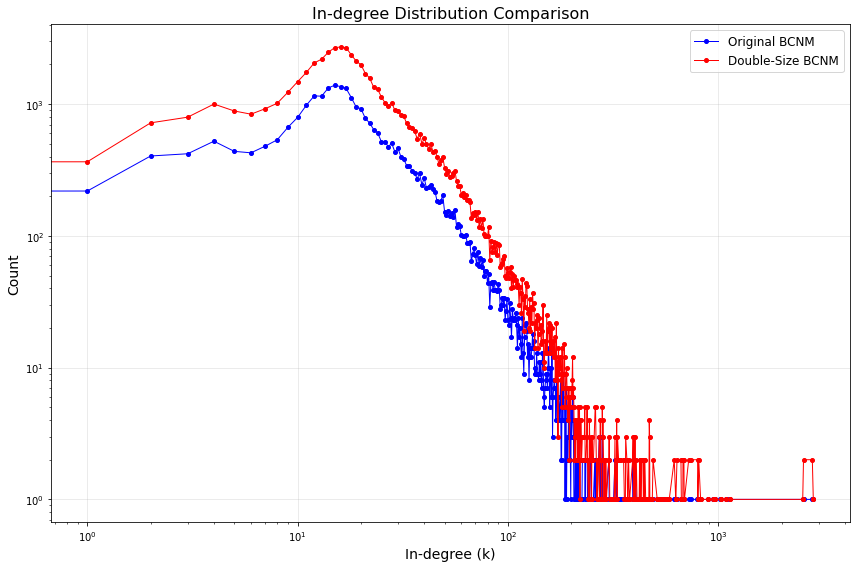

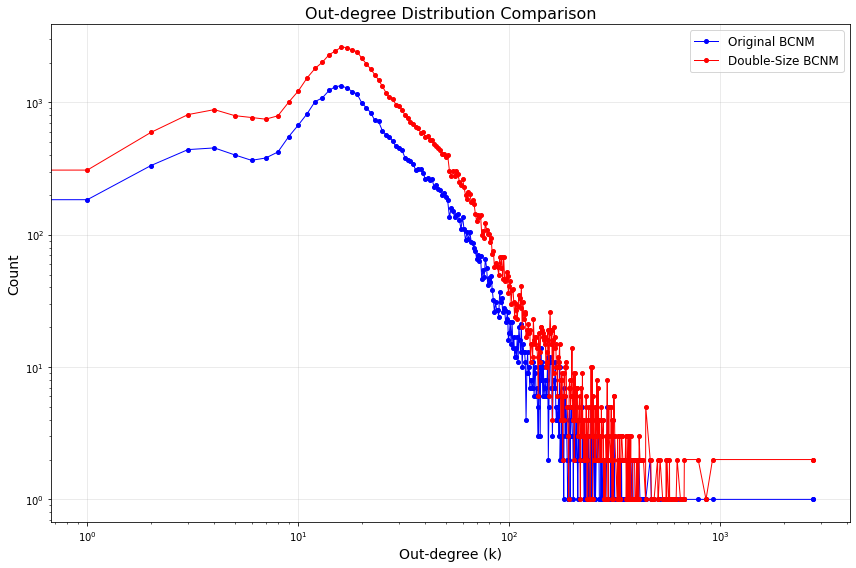

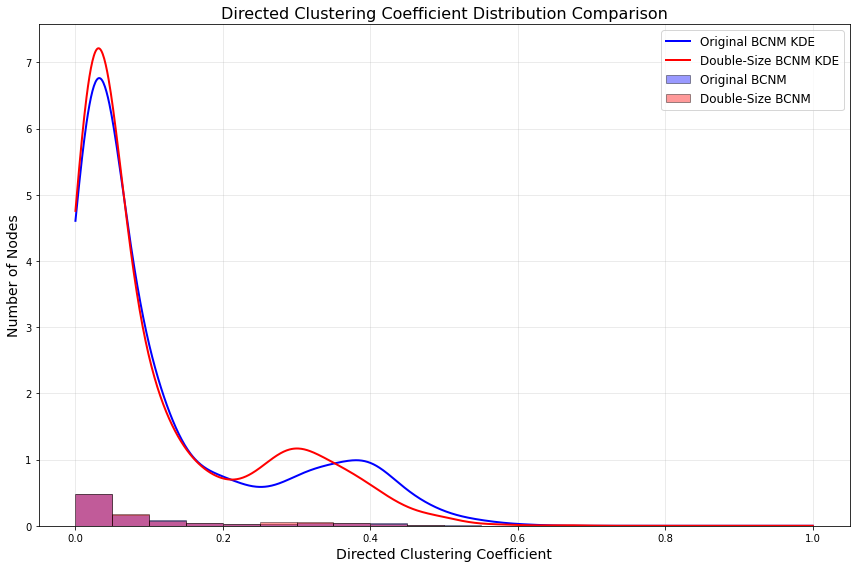

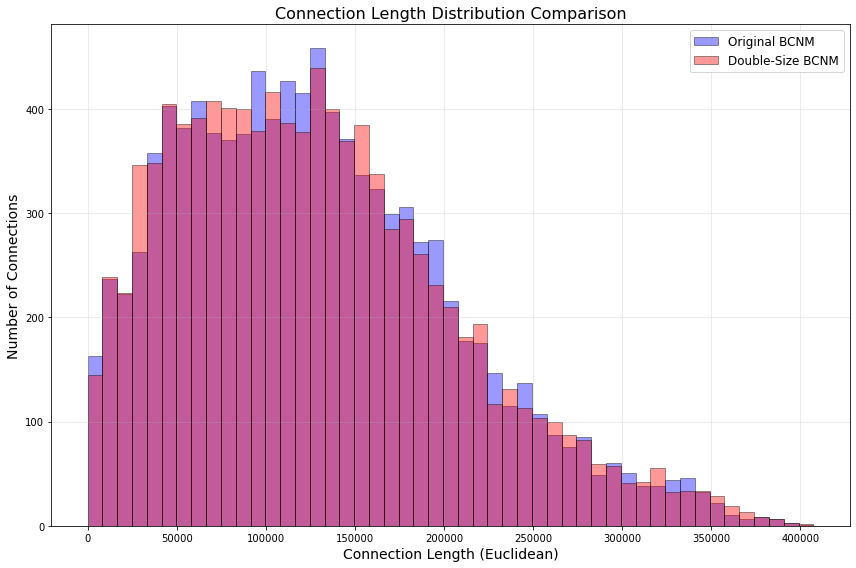

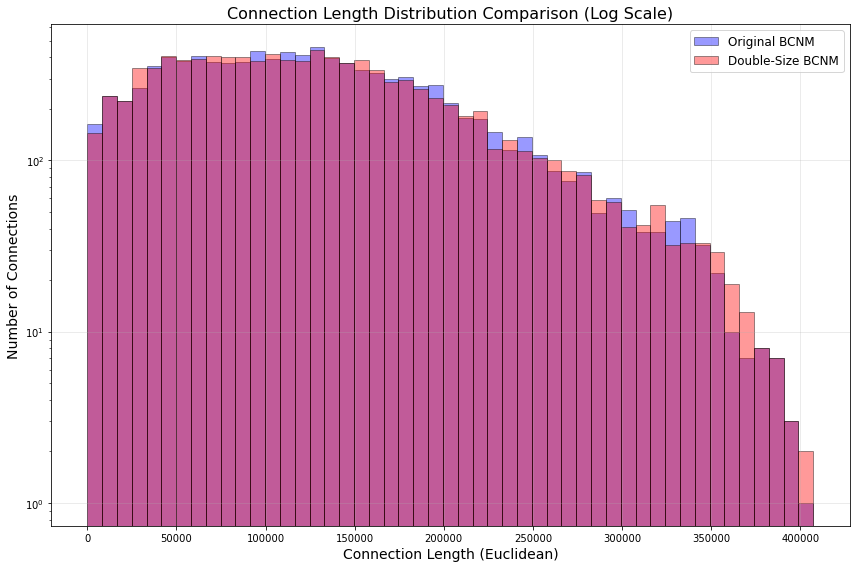

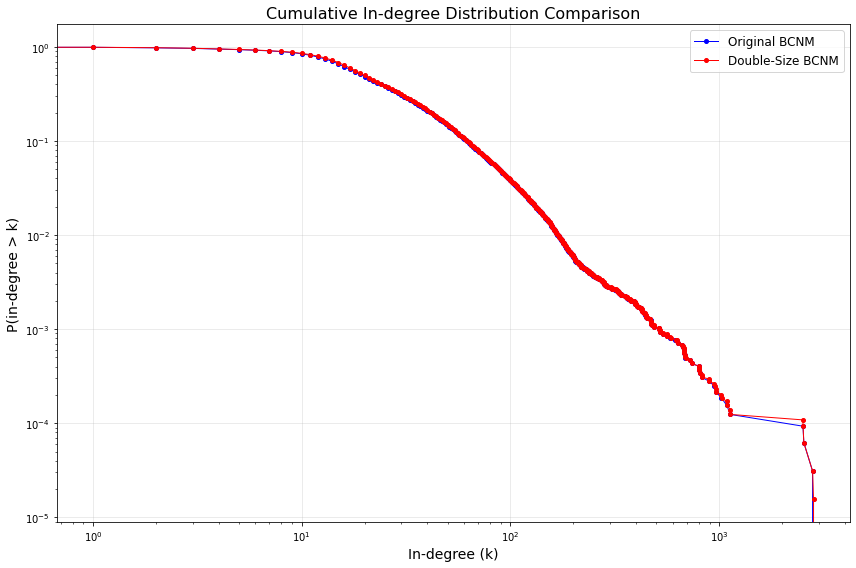

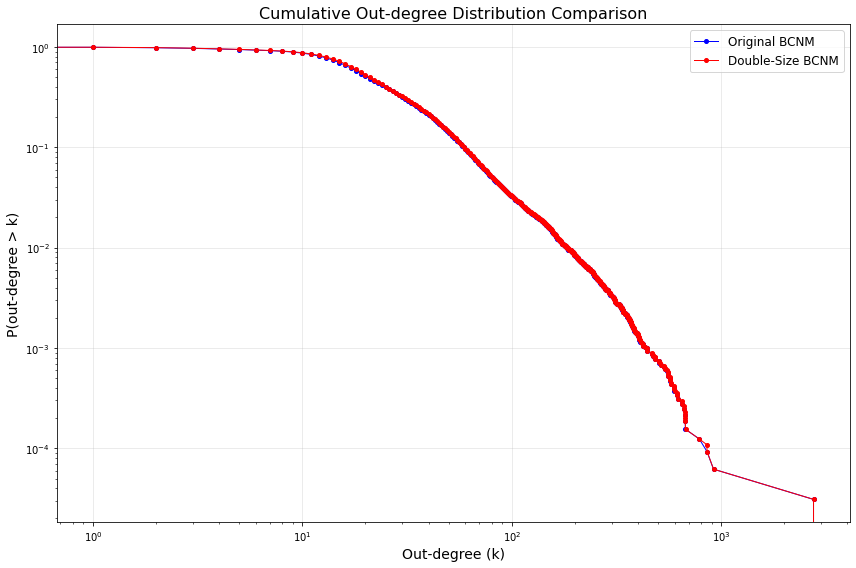

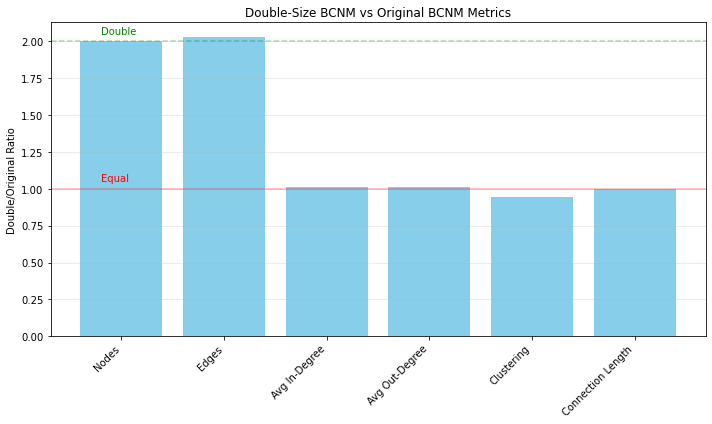

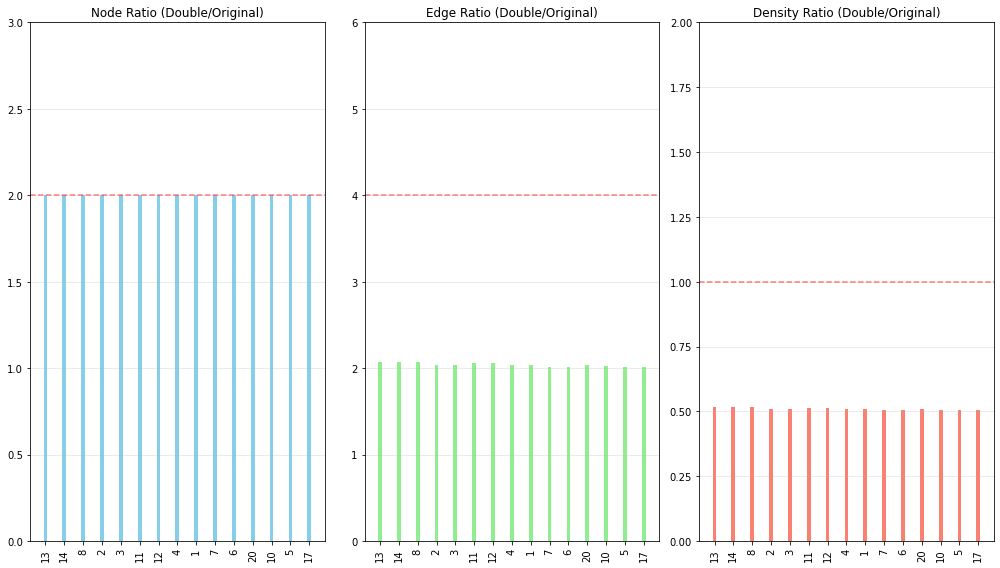

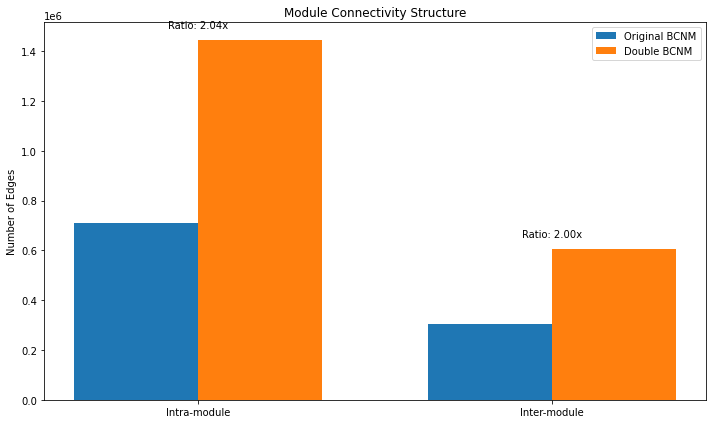

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting BCNM model doubling process...")
start_time = time.time()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created 'plots' directory")

# Load the original BCNM model
print("Loading original BCNM model...")
bcnm_edges_df = pd.read_csv("bcnm_edges.csv")
bcnm_metadata_df = pd.read_csv("bcnm_metadata.csv")
print(f"Loaded {len(bcnm_edges_df)} edges and {len(bcnm_metadata_df)} nodes from BCNM files")

# Create the original BCNM graph
print("Creating original BCNM graph...")
bcnm = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in bcnm_metadata_df.iterrows():
    node_id = node_data['node_id']
    attrs = {}
    for col in bcnm_metadata_df.columns:
        if col != 'node_id':
            attrs[col] = node_data[col]
    bcnm.add_node(node_id, **attrs)

# Add edges
print("Adding edges...")
for _, edge in bcnm_edges_df.iterrows():
    bcnm.add_edge(edge['from'], edge['to'])

print(f"Original BCNM graph: {bcnm.number_of_nodes()} nodes, {bcnm.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(bcnm, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate network metrics for the original BCNM
print("Calculating network metrics for original BCNM...")
in_degrees = dict(bcnm.in_degree())
out_degrees = dict(bcnm.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in bcnm.nodes()}

# Calculate directed clustering coefficient
print("Calculating directed clustering coefficient...")
def directed_clustering_coefficient(G, nodes_to_sample=None):
    """Calculate directed clustering coefficient for nodes in a graph."""
    if nodes_to_sample is None:
        nodes_to_sample = G.nodes()
    
    clustering = {}
    print(f"Processing {len(nodes_to_sample)} nodes for directed clustering...")
    
    for i, node in enumerate(nodes_to_sample):
        if i % 1000 == 0 and i > 0:
            print(f"  Processed {i}/{len(nodes_to_sample)} nodes")
            
        # Get predecessors and successors
        preds = list(G.predecessors(node))
        succs = list(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # For large nodes, sample to improve performance
        if possible_triangles > 1000:
            # Sample predecessor-successor pairs
            sample_size = 1000
            pred_sample = random.sample(preds, min(len(preds), int(np.sqrt(sample_size))))
            succ_sample = random.sample(succs, min(len(succs), int(sample_size / len(pred_sample))))
            
            # Count triangles in sample
            triangles = sum(1 for p in pred_sample for s in succ_sample if G.has_edge(p, s))
            
            # Estimate full count
            actual_triangles = (triangles / (len(pred_sample) * len(succ_sample))) * possible_triangles
        else:
            # Count all triangles
            actual_triangles = sum(1 for p in preds for s in succs if G.has_edge(p, s))
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

# Sample nodes for calculating directed clustering coefficient
print("Sampling nodes for clustering coefficient calculation...")
sample_size = min(2000, bcnm.number_of_nodes())
nodes_to_sample = random.sample(list(bcnm.nodes()), sample_size)
bcnm_clustering = directed_clustering_coefficient(bcnm, nodes_to_sample)

print(f"Calculated directed clustering for {len(bcnm_clustering)} nodes")
avg_clustering = sum(bcnm_clustering.values()) / len(bcnm_clustering)
print(f"Original BCNM average directed clustering coefficient: {avg_clustering:.4f}")

# Function to calculate Euclidean distance between nodes
def calculate_euclidean_distance(graph, edge):
    u, v = edge
    try:
        u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
        v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
        return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
    except KeyError:
        return None

# Sample edges for distance calculation
print("Calculating connection lengths for original BCNM (sampled)...")
MAX_DISTANCE_SAMPLES = 10000
edges_to_sample = random.sample(list(bcnm.edges()), min(MAX_DISTANCE_SAMPLES, bcnm.number_of_edges()))
bcnm_distances = []
for edge in edges_to_sample:
    distance = calculate_euclidean_distance(bcnm, edge)
    if distance is not None:
        bcnm_distances.append(distance)
avg_distance = np.mean(bcnm_distances)
print(f"Original BCNM average connection length (sampled): {avg_distance:.4f}")

# Calculate network density
original_density = bcnm.number_of_edges() / (bcnm.number_of_nodes() * (bcnm.number_of_nodes() - 1))
print(f"Original BCNM density: {original_density:.8f}")

##########################
# Create Double-Size BCNM
##########################
print("\nCreating double-size BCNM...")
double_bcnm = nx.DiGraph()

# Function to generate small random displacement for spatial coordinates
def generate_displacement(scale=0.1):
    return np.random.normal(0, scale, 3)  # For x, y, z coordinates

# First, add all original nodes
print("Adding original nodes to double-size graph...")
for node in bcnm.nodes():
    double_bcnm.add_node(node, **bcnm.nodes[node])

# Then, create duplicate nodes with slight variations to create new nodes
print("Creating duplicate nodes for double-size graph...")
node_to_duplicate = {}  # Mapping from original node to its duplicate

# First duplicate all nodes with metadata
duplicate_count = 0
for node in bcnm.nodes():
    # Generate a new node ID
    new_node = f"dup_{node}"
    
    # Copy attributes with slight spatial variation
    attrs = dict(bcnm.nodes[node])
    if 'x' in attrs and 'y' in attrs and 'z' in attrs:
        # Add small random displacement to coordinates
        displacement = generate_displacement()
        attrs['x'] += displacement[0]
        attrs['y'] += displacement[1]
        attrs['z'] += displacement[2]
    
    # Add the duplicate node
    double_bcnm.add_node(new_node, **attrs)
    node_to_duplicate[node] = new_node
    duplicate_count += 1
    
    if duplicate_count % 1000 == 0:
        print(f"  Created {duplicate_count} duplicate nodes")

print(f"Created {duplicate_count} duplicate nodes")
print(f"Double-size graph has {double_bcnm.number_of_nodes()} nodes")

# Add all edges from the original BCNM
print("Adding original edges to double-size graph...")
double_bcnm.add_edges_from(bcnm.edges())
print(f"Added {bcnm.number_of_edges()} original edges")

# Add edges to connect duplicate nodes
print("Adding edges between duplicate nodes...")
added_edges = 0

# Create edges between duplicates based on original edges
duplicate_edges = []
for u, v in bcnm.edges():
    # Duplicate -> Duplicate (similar to original pattern)
    duplicate_edges.append((node_to_duplicate[u], node_to_duplicate[v]))
    
    # Every 10,000 edges, report progress
    if len(duplicate_edges) % 10000 == 0:
        print(f"  Generated {len(duplicate_edges)} duplicate edges")

double_bcnm.add_edges_from(duplicate_edges)
added_edges += len(duplicate_edges)
print(f"Added {added_edges} duplicate edges")

# Now add cross-connections between original and duplicate nodes by module
print("Creating cross-connections between original and duplicate modules...")
cross_connections = 0

# For each module, add connections between original and duplicate nodes
for module, nodes in nodes_by_module.items():
    original_module_nodes = nodes
    duplicate_module_nodes = [node_to_duplicate[node] for node in nodes]
    
    # Calculate the number of cross-connections to add
    # Use a fraction of the possible connections to maintain overall density
    cross_connection_density = original_density * 0.5  # Use lower density for cross-connections
    possible_connections = len(original_module_nodes) * len(duplicate_module_nodes)
    target_connections = int(cross_connection_density * possible_connections)
    
    print(f"Module {module}: Adding {target_connections} cross-connections")
    
    # Generate random cross-connections
    connections_added = 0
    attempts = 0
    max_attempts = target_connections * 5  # Limit attempts to avoid infinite loops
    
    while connections_added < target_connections and attempts < max_attempts:
        u = random.choice(original_module_nodes)
        v = random.choice(duplicate_module_nodes)
        
        # Add connection in both directions with equal probability
        if random.random() < 0.5:
            if not double_bcnm.has_edge(u, v):
                double_bcnm.add_edge(u, v)
                connections_added += 1
        else:
            if not double_bcnm.has_edge(v, u):
                double_bcnm.add_edge(v, u)
                connections_added += 1
        
        attempts += 1
    
    cross_connections += connections_added
    
    # Report progress every few modules
    if len(original_module_nodes) > 100:
        print(f"  Added {connections_added} cross-connections for module {module}")

print(f"Added a total of {cross_connections} cross-connections between original and duplicate modules")
print(f"Double-size BCNM: {double_bcnm.number_of_nodes()} nodes, {double_bcnm.number_of_edges()} edges")

# Calculate network metrics for the double-size BCNM
print("\nCalculating network metrics for double-size BCNM...")
double_in_degrees = dict(double_bcnm.in_degree())
double_out_degrees = dict(double_bcnm.out_degree())
double_total_degrees = {node: double_in_degrees[node] + double_out_degrees[node] for node in double_bcnm.nodes()}

# Sample nodes for calculating directed clustering coefficient
print("Sampling nodes for double-size BCNM clustering coefficient calculation...")
double_sample_size = min(2000, double_bcnm.number_of_nodes())
double_nodes_to_sample = random.sample(list(double_bcnm.nodes()), double_sample_size)
double_clustering = directed_clustering_coefficient(double_bcnm, double_nodes_to_sample)

print(f"Calculated directed clustering for {len(double_clustering)} nodes in double-size BCNM")
double_avg_clustering = sum(double_clustering.values()) / len(double_clustering)
print(f"Double-size BCNM average directed clustering coefficient: {double_avg_clustering:.4f}")

# Sample edges for distance calculation
print("Calculating connection lengths for double-size BCNM (sampled)...")
double_edges_to_sample = random.sample(list(double_bcnm.edges()), min(MAX_DISTANCE_SAMPLES, double_bcnm.number_of_edges()))
double_distances = []
for edge in double_edges_to_sample:
    distance = calculate_euclidean_distance(double_bcnm, edge)
    if distance is not None:
        double_distances.append(distance)
double_avg_distance = np.mean(double_distances)
print(f"Double-size BCNM average connection length (sampled): {double_avg_distance:.4f}")

# Calculate network density
double_density = double_bcnm.number_of_edges() / (double_bcnm.number_of_nodes() * (double_bcnm.number_of_nodes() - 1))
print(f"Double-size BCNM density: {double_density:.8f}")
print(f"Density ratio (Double/Original): {double_density/original_density:.4f}")

####################
# Generate plots comparing the original and double-size models
####################
print("\nGenerating comparison plots...")

# Plot in-degree distribution comparison
print("Plotting in-degree distribution...")
plt.figure(figsize=(12, 8))
original_in_degrees = list(dict(bcnm.in_degree()).values())
double_in_degrees = list(dict(double_bcnm.in_degree()).values())

plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(double_in_degrees).keys()), 
           [Counter(double_in_degrees)[k] for k in sorted(Counter(double_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
print("Plotting out-degree distribution...")
plt.figure(figsize=(12, 8))
original_out_degrees = list(dict(bcnm.out_degree()).values())
double_out_degrees = list(dict(double_bcnm.out_degree()).values())

plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(double_out_degrees).keys()), 
           [Counter(double_out_degrees)[k] for k in sorted(Counter(double_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Normalize histograms by scaling counts
orig_weights = np.ones_like(list(bcnm_clustering.values())) / len(bcnm_clustering)
double_weights = np.ones_like(list(double_clustering.values())) / len(double_clustering)

plt.hist(list(bcnm_clustering.values()), bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM', weights=orig_weights)
plt.hist(list(double_clustering.values()), bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size BCNM', weights=double_weights)

# Add kernel density estimation
kde_bcnm = gaussian_kde(list(bcnm_clustering.values()))
kde_double = gaussian_kde(list(double_clustering.values()))
x_vals = np.linspace(0, 1, 1000)

plt.plot(x_vals, kde_bcnm(x_vals), 'b-', linewidth=2, label='Original BCNM KDE')
plt.plot(x_vals, kde_double(x_vals), 'r-', linewidth=2, label='Double-Size BCNM KDE')

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_clustering_coefficient.png', dpi=600)
print("Saved clustering coefficient distribution comparison plot at 600dpi")

# Plot connection length distributions
print("Plotting connection length distributions...")
plt.figure(figsize=(12, 8))
max_distance = max(np.max(bcnm_distances), np.max(double_distances))
bins = np.linspace(0, max_distance, 50)

plt.hist(bcnm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(double_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
print("Plotting connection length distributions with log scale...")
plt.figure(figsize=(12, 8))
plt.hist(bcnm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(double_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_connection_length_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot at 600dpi")

# Helper function for cumulative distribution calculation
def compute_cumulative_dist(degrees):
    counter = Counter(degrees)
    sorted_degrees = sorted(counter.items())
    total_nodes = sum(counter.values())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    return x_vals, y_vals

# Calculate cumulative distributions
print("Calculating cumulative degree distributions...")
x_bcnm_in, y_bcnm_in = compute_cumulative_dist(original_in_degrees)
x_double_in, y_double_in = compute_cumulative_dist(double_in_degrees)

# Plot cumulative in-degree distribution
print("Plotting cumulative in-degree distribution...")
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_in, y_bcnm_in, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_double_in, y_double_in, 'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot at 600dpi")

# Calculate out-degree cumulative distributions
x_bcnm_out, y_bcnm_out = compute_cumulative_dist(original_out_degrees)
x_double_out, y_double_out = compute_cumulative_dist(double_out_degrees)

# Plot cumulative out-degree distribution
print("Plotting cumulative out-degree distribution...")
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_out, y_bcnm_out, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_double_out, y_double_out, 'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot at 600dpi")

# Perform statistical tests to compare distributions
print("\nPerforming statistical comparison of distributions...")
# Sample distributions for statistical comparison
def sample_for_stats(data, max_samples=1000):
    if len(data) > max_samples:
        return random.sample(data, max_samples)
    return data

# Get samples for testing
original_in_sample = sample_for_stats(original_in_degrees)
double_in_sample = sample_for_stats(double_in_degrees)
original_out_sample = sample_for_stats(original_out_degrees)
double_out_sample = sample_for_stats(double_out_degrees)
original_cc_sample = sample_for_stats(list(bcnm_clustering.values()))
double_cc_sample = sample_for_stats(list(double_clustering.values()))
original_dist_sample = sample_for_stats(bcnm_distances)
double_dist_sample = sample_for_stats(double_distances)

# Perform KS tests
ks_in_degree = ks_2samp(original_in_sample, double_in_sample)
ks_out_degree = ks_2samp(original_out_sample, double_out_sample)
ks_clustering = ks_2samp(original_cc_sample, double_cc_sample)
ks_distances = ks_2samp(original_dist_sample, double_dist_sample)

print("\nKolmogorov-Smirnov Test Results (Original vs Double-Size):")
print(f"In-degree distributions: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.6f}")
print(f"Out-degree distributions: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.6f}")
print(f"Clustering coefficient distributions: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.6f}")
print(f"Connection length distributions: statistic={ks_distances.statistic:.4f}, p-value={ks_distances.pvalue:.6f}")

# Calculate mean values for key metrics
print("\nSummary Statistics:")
print(f"Mean in-degree: Original={np.mean(original_in_degrees):.2f}, Double-Size={np.mean(double_in_degrees):.2f}")
print(f"Mean out-degree: Original={np.mean(original_out_degrees):.2f}, Double-Size={np.mean(double_out_degrees):.2f}")
print(f"Mean clustering coefficient: Original={avg_clustering:.4f}, Double-Size={double_avg_clustering:.4f}")
print(f"Mean connection length: Original={avg_distance:.4f}, Double-Size={double_avg_distance:.4f}")

# Generate comparison metrics chart
print("\nGenerating metrics comparison chart...")
plt.figure(figsize=(10, 6))
metrics = ['Nodes', 'Edges', 'Avg In-Degree', 'Avg Out-Degree', 'Clustering', 'Connection Length']
original_values = [bcnm.number_of_nodes(), bcnm.number_of_edges(), 
                   np.mean(original_in_degrees), np.mean(original_out_degrees),
                   avg_clustering, avg_distance]
double_values = [double_bcnm.number_of_nodes(), double_bcnm.number_of_edges(),
                np.mean(double_in_degrees), np.mean(double_out_degrees),
                double_avg_clustering, double_avg_distance]

# Normalize by original values
ratio_values = [double_values[i]/original_values[i] for i in range(len(metrics))]

# Plot the ratios
plt.bar(metrics, ratio_values, color='skyblue')
plt.axhline(y=1.0, color='r', linestyle='-', alpha=0.3)
plt.axhline(y=2.0, color='g', linestyle='--', alpha=0.3)
plt.text(-0.2, 1.05, "Equal", color='r')
plt.text(-0.2, 2.05, "Double", color='g')

plt.ylabel('Double/Original Ratio')
plt.title('Double-Size BCNM vs Original BCNM Metrics')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/double_bcnm_metrics_comparison.png', dpi=600)
print("Saved metrics comparison chart at 600dpi")

####################
# Export CSV files
####################
print("\nExporting double-size BCNM model to CSV files...")

# Export edges
print("Exporting edges data...")
double_edges = list(double_bcnm.edges())
double_edges_df = pd.DataFrame(double_edges, columns=['from', 'to'])
double_edges_df.to_csv('double_size_bcnm_edges.csv', index=False)

# Export node metadata
print("Exporting node metadata...")
double_nodes = []
for node, data in double_bcnm.nodes(data=True):
    node_data = {
        'node_id': node
    }
    for key, value in data.items():
        node_data[key] = value
    double_nodes.append(node_data)
double_metadata_df = pd.DataFrame(double_nodes)
double_metadata_df.to_csv('double_size_bcnm_metadata.csv', index=False)

print("CSV exports completed successfully!")

# Module-by-module comparison
print("\nPerforming module-by-module comparison...")

# Identify common modules in both graphs
original_modules = set(modules.values())
double_modules = set(nx.get_node_attributes(double_bcnm, 'module').values())
common_modules = original_modules.intersection(double_modules)

print(f"Found {len(common_modules)} modules common to both graphs")

# Calculate statistics for each module
module_stats = []
for module in sorted(list(common_modules)):
    print(f"Analyzing module {module}...")
    
    # Get nodes for this module in original graph
    orig_module_nodes = [n for n, m in modules.items() if m == module]
    # Get nodes for this module in double graph (both original and duplicated)
    double_module_nodes = [n for n, m in nx.get_node_attributes(double_bcnm, 'module').items() if m == module]
    
    # Calculate subgraph metrics
    orig_subgraph = bcnm.subgraph(orig_module_nodes)
    double_subgraph = double_bcnm.subgraph(double_module_nodes)
    
    # Node and edge counts
    orig_nodes = orig_subgraph.number_of_nodes()
    double_nodes = double_subgraph.number_of_nodes()
    orig_edges = orig_subgraph.number_of_edges()
    double_edges = double_subgraph.number_of_edges()
    
    # Average degrees
    orig_avg_in = np.mean([d for n, d in orig_subgraph.in_degree()])
    double_avg_in = np.mean([d for n, d in double_subgraph.in_degree()])
    orig_avg_out = np.mean([d for n, d in orig_subgraph.out_degree()])
    double_avg_out = np.mean([d for n, d in double_subgraph.out_degree()])
    
    # Calculate directed clustering for samples from this module
    if len(orig_module_nodes) > 10:
        orig_sample = random.sample(orig_module_nodes, min(100, len(orig_module_nodes)))
        orig_cc = directed_clustering_coefficient(bcnm, orig_sample)
        orig_avg_cc = np.mean(list(orig_cc.values())) if orig_cc else 0
    else:
        orig_avg_cc = 0
        
    if len(double_module_nodes) > 10:
        double_sample = random.sample(double_module_nodes, min(100, len(double_module_nodes)))
        double_cc = directed_clustering_coefficient(double_bcnm, double_sample)
        double_avg_cc = np.mean(list(double_cc.values())) if double_cc else 0
    else:
        double_avg_cc = 0
    
    # Calculate module density
    if orig_nodes > 1:
        orig_density = orig_edges / (orig_nodes * (orig_nodes - 1))
    else:
        orig_density = 0
        
    if double_nodes > 1:
        double_density = double_edges / (double_nodes * (double_nodes - 1))
    else:
        double_density = 0
    
    # Store statistics
    module_stats.append({
        'module': module,
        'orig_nodes': orig_nodes,
        'double_nodes': double_nodes,
        'orig_edges': orig_edges,
        'double_edges': double_edges,
        'orig_avg_in': orig_avg_in,
        'double_avg_in': double_avg_in,
        'orig_avg_out': orig_avg_out,
        'double_avg_out': double_avg_out,
        'orig_avg_cc': orig_avg_cc,
        'double_avg_cc': double_avg_cc,
        'orig_density': orig_density,
        'double_density': double_density,
        'node_ratio': double_nodes / max(1, orig_nodes),
        'edge_ratio': double_edges / max(1, orig_edges),
        'density_ratio': double_density / max(0.0001, orig_density)
    })

# Create a dataframe for better display
module_df = pd.DataFrame(module_stats)

# Print summary statistics
print("\nModule-by-module comparison (top 10 modules by node count):")
top_modules = module_df.sort_values('orig_nodes', ascending=False).head(10)

print(top_modules[['module', 'orig_nodes', 'double_nodes', 'node_ratio', 
                   'orig_edges', 'double_edges', 'edge_ratio',
                   'orig_density', 'double_density', 'density_ratio']].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Calculate average ratios
avg_node_ratio = module_df['node_ratio'].mean()
avg_edge_ratio = module_df['edge_ratio'].mean()
avg_density_ratio = module_df['density_ratio'].mean()

print(f"\nAverage node ratio across modules: {avg_node_ratio:.3f}")
print(f"Average edge ratio across modules: {avg_edge_ratio:.3f}")
print(f"Average density ratio across modules: {avg_density_ratio:.3f}")

# Create module comparison visualization
print("\nGenerating module comparison visualization...")
plt.figure(figsize=(14, 8))

# Select top 15 modules by node count for visualization
vis_modules = module_df.sort_values('orig_nodes', ascending=False).head(15)
x = np.arange(len(vis_modules))
width = 0.2

# Plot node ratios
plt.subplot(1, 3, 1)
plt.bar(x, vis_modules['node_ratio'], width, color='skyblue')
plt.axhline(y=2.0, color='r', linestyle='--', alpha=0.5)
plt.title('Node Ratio (Double/Original)')
plt.xticks(x, vis_modules['module'], rotation=90)
plt.ylim(0, 3)
plt.grid(axis='y', alpha=0.3)

# Plot edge ratios
plt.subplot(1, 3, 2)
plt.bar(x, vis_modules['edge_ratio'], width, color='lightgreen')
plt.axhline(y=4.0, color='r', linestyle='--', alpha=0.5)
plt.title('Edge Ratio (Double/Original)')
plt.xticks(x, vis_modules['module'], rotation=90)
plt.ylim(0, 6)
plt.grid(axis='y', alpha=0.3)

# Plot density ratios
plt.subplot(1, 3, 3)
plt.bar(x, vis_modules['density_ratio'], width, color='salmon')
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
plt.title('Density Ratio (Double/Original)')
plt.xticks(x, vis_modules['module'], rotation=90)
plt.ylim(0, 2)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/module_comparison.png', dpi=600)
print("Saved module comparison visualization at 600dpi")

# Additional module structure visualization - intra vs inter module connections
print("\nAnalyzing module connectivity structure...")

# Count intra-module vs inter-module edges
def count_module_edges(G):
    modules_attr = nx.get_node_attributes(G, 'module')
    intra_module = 0
    inter_module = 0
    
    for u, v in G.edges():
        if modules_attr.get(u) == modules_attr.get(v):
            intra_module += 1
        else:
            inter_module += 1
    
    return intra_module, inter_module

orig_intra, orig_inter = count_module_edges(bcnm)
double_intra, double_inter = count_module_edges(double_bcnm)

print(f"Original BCNM: {orig_intra} intra-module edges, {orig_inter} inter-module edges")
print(f"Double BCNM: {double_intra} intra-module edges, {double_inter} inter-module edges")
print(f"Intra-module edge ratio: {double_intra/orig_intra:.3f}")
print(f"Inter-module edge ratio: {double_inter/orig_inter:.3f}")

# Visualize the intra/inter module edge distribution
plt.figure(figsize=(10, 6))
labels = ['Intra-module', 'Inter-module']
orig_values = [orig_intra, orig_inter]
double_values = [double_intra, double_inter]
ratios = [double_intra/orig_intra, double_inter/orig_inter]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, orig_values, width, label='Original BCNM')
plt.bar(x + width/2, double_values, width, label='Double BCNM')

plt.title('Module Connectivity Structure')
plt.xticks(x, labels)
plt.ylabel('Number of Edges')
plt.legend()

# Add ratio annotations
for i, ratio in enumerate(ratios):
    plt.annotate(f'Ratio: {ratio:.2f}x', 
                 xy=(i, double_values[i]), 
                 xytext=(0, 10),
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.tight_layout()
plt.savefig('plots/module_connectivity.png', dpi=600)
print("Saved module connectivity structure at 600dpi")

# Print execution time
end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")
print("Double-size BCNM model generation complete!")

Starting BCNM model doubling process...
Loading original BCNM model...
Loaded 1011690 edges and 32272 nodes from BCNM files
Creating original BCNM graph...
Adding nodes with metadata...
Adding edges...
Original BCNM graph: 32272 nodes, 1011690 edges
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating network metrics for original BCNM...
Calculating directed clustering coefficient...
Sampling nodes for clustering coefficient calculation...
Processing 2000 nodes for directed clustering...
  Processed 1000/2000 nodes
Calculated directed clustering for 2000 nodes
Original BCNM average directed clustering coefficient: 0.1189
Calculating connection lengths for original BCNM (sampled)...
Original BCNM average connection length (sampled): 128525.2382
Original BCNM density: 0.00097142

Creating double-size BCNM...
Adding original nodes to double-size graph...
Creating duplicate nodes for double-size graph...
  Created 1000 duplicate nodes
  Created 2

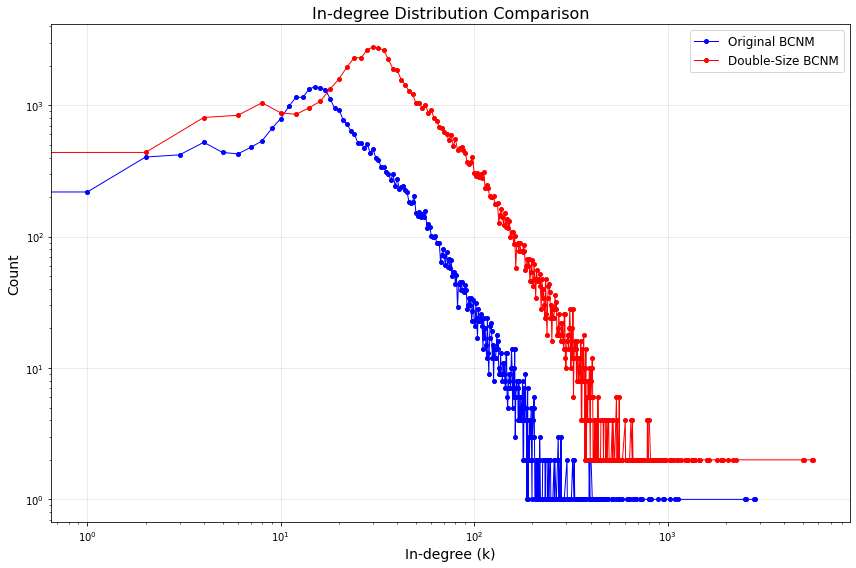

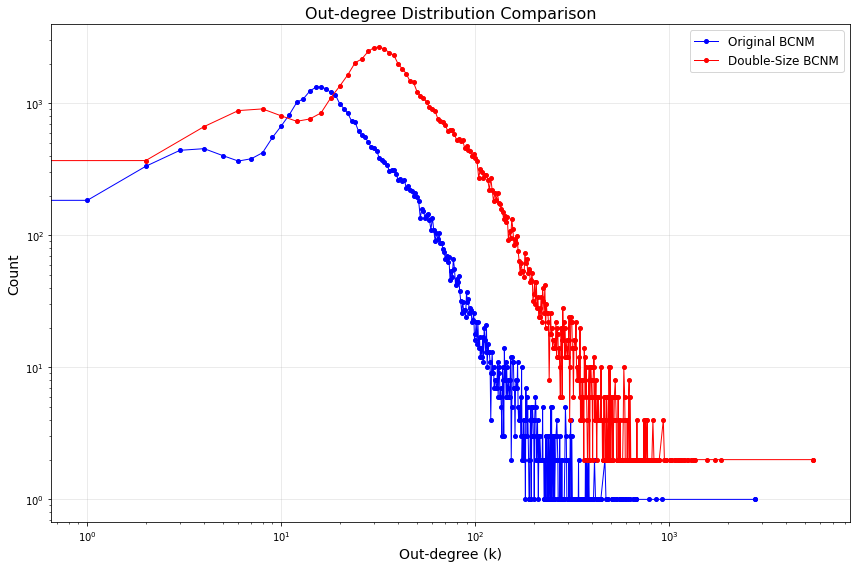

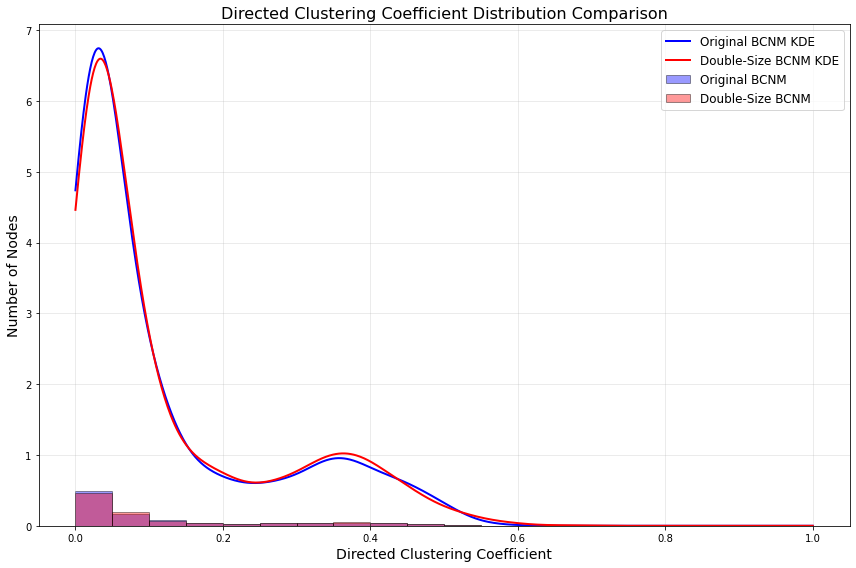

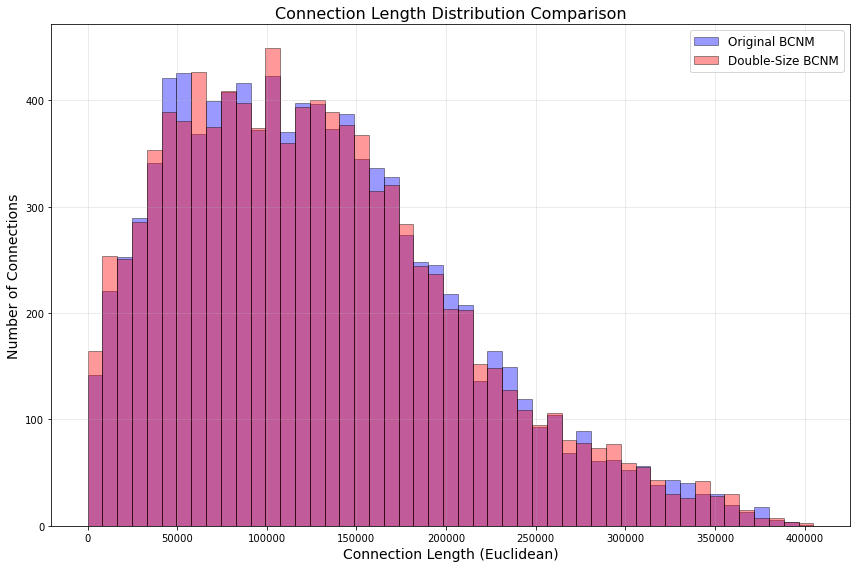

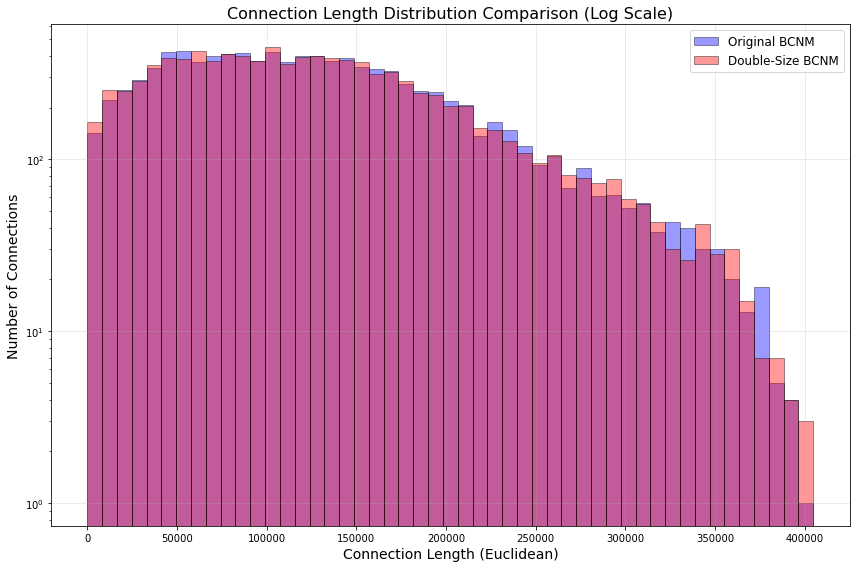

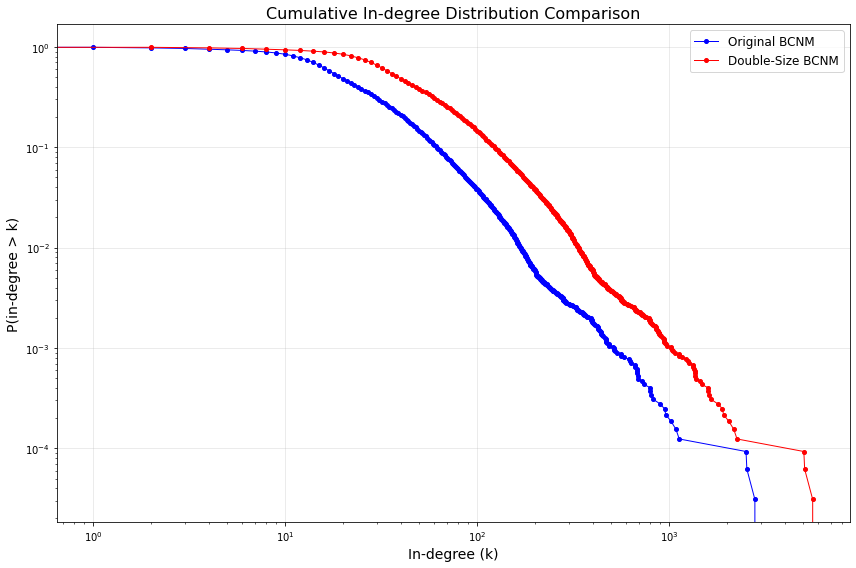

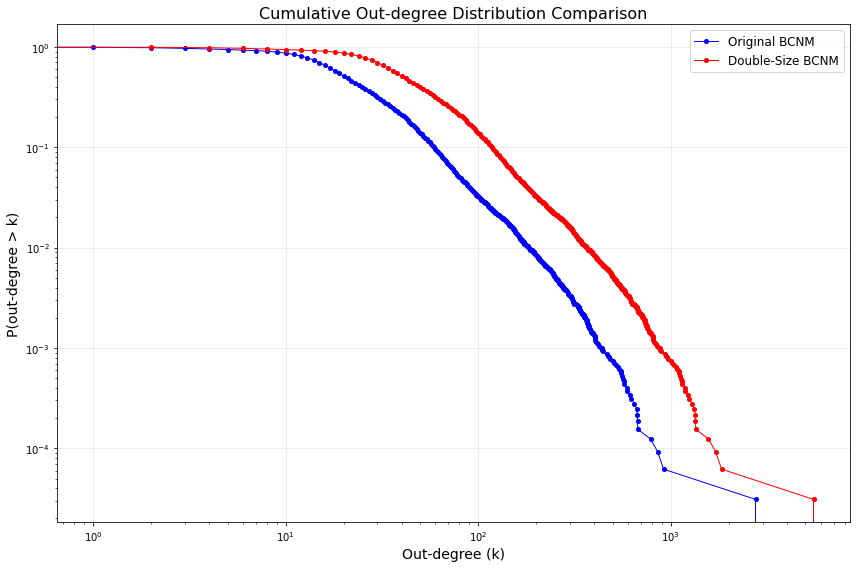

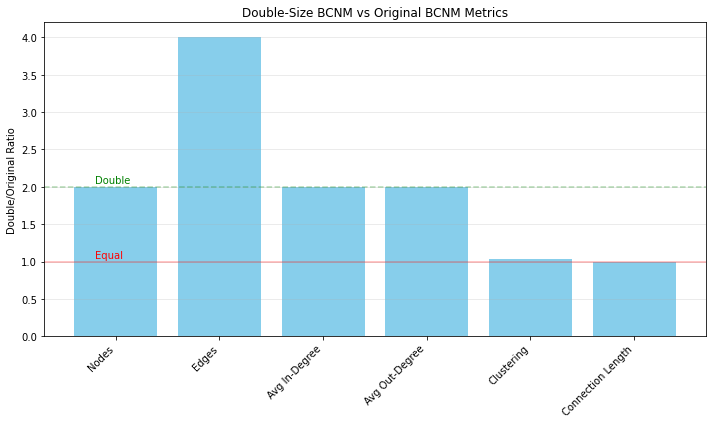

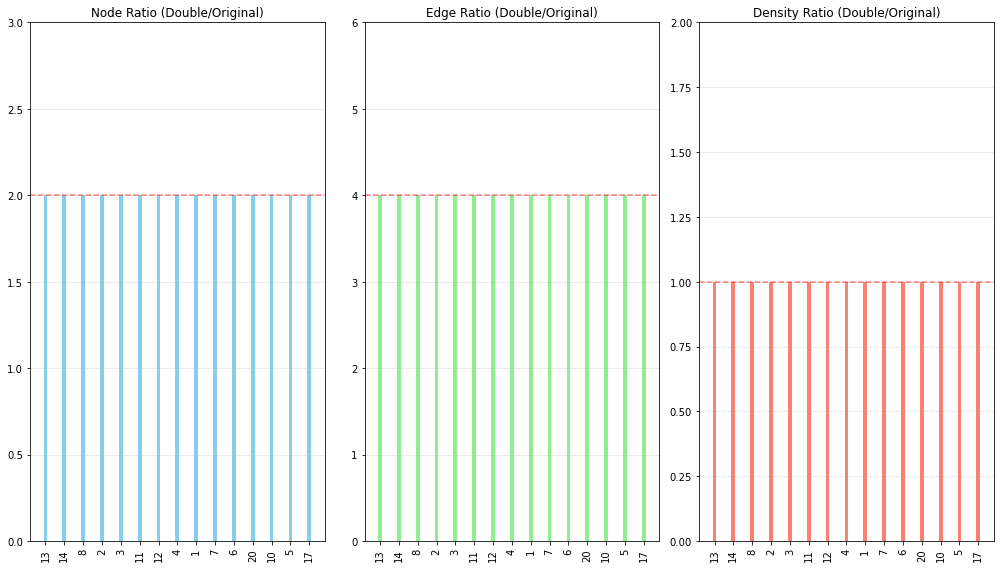

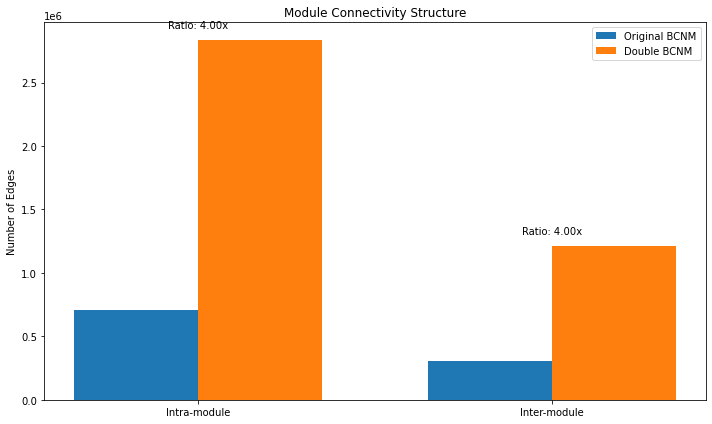

In [4]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting BCNM model doubling process...")
start_time = time.time()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created 'plots' directory")

# Load the original BCNM model
print("Loading original BCNM model...")
bcnm_edges_df = pd.read_csv("bcnm_edges.csv")
bcnm_metadata_df = pd.read_csv("bcnm_metadata.csv")
print(f"Loaded {len(bcnm_edges_df)} edges and {len(bcnm_metadata_df)} nodes from BCNM files")

# Create the original BCNM graph
print("Creating original BCNM graph...")
bcnm = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in bcnm_metadata_df.iterrows():
    node_id = node_data['node_id']
    attrs = {}
    for col in bcnm_metadata_df.columns:
        if col != 'node_id':
            attrs[col] = node_data[col]
    bcnm.add_node(node_id, **attrs)

# Add edges
print("Adding edges...")
for _, edge in bcnm_edges_df.iterrows():
    bcnm.add_edge(edge['from'], edge['to'])

print(f"Original BCNM graph: {bcnm.number_of_nodes()} nodes, {bcnm.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(bcnm, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate network metrics for the original BCNM
print("Calculating network metrics for original BCNM...")
in_degrees = dict(bcnm.in_degree())
out_degrees = dict(bcnm.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in bcnm.nodes()}

# Calculate directed clustering coefficient
print("Calculating directed clustering coefficient...")
def directed_clustering_coefficient(G, nodes_to_sample=None):
    """Calculate directed clustering coefficient for nodes in a graph."""
    if nodes_to_sample is None:
        nodes_to_sample = G.nodes()
    
    clustering = {}
    print(f"Processing {len(nodes_to_sample)} nodes for directed clustering...")
    
    for i, node in enumerate(nodes_to_sample):
        if i % 1000 == 0 and i > 0:
            print(f"  Processed {i}/{len(nodes_to_sample)} nodes")
            
        # Get predecessors and successors
        preds = list(G.predecessors(node))
        succs = list(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # For large nodes, sample to improve performance
        if possible_triangles > 1000:
            # Sample predecessor-successor pairs
            sample_size = 1000
            pred_sample = random.sample(preds, min(len(preds), int(np.sqrt(sample_size))))
            succ_sample = random.sample(succs, min(len(succs), int(sample_size / len(pred_sample))))
            
            # Count triangles in sample
            triangles = sum(1 for p in pred_sample for s in succ_sample if G.has_edge(p, s))
            
            # Estimate full count
            actual_triangles = (triangles / (len(pred_sample) * len(succ_sample))) * possible_triangles
        else:
            # Count all triangles
            actual_triangles = sum(1 for p in preds for s in succs if G.has_edge(p, s))
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

# Sample nodes for calculating directed clustering coefficient
print("Sampling nodes for clustering coefficient calculation...")
sample_size = min(2000, bcnm.number_of_nodes())
nodes_to_sample = random.sample(list(bcnm.nodes()), sample_size)
bcnm_clustering = directed_clustering_coefficient(bcnm, nodes_to_sample)

print(f"Calculated directed clustering for {len(bcnm_clustering)} nodes")
avg_clustering = sum(bcnm_clustering.values()) / len(bcnm_clustering)
print(f"Original BCNM average directed clustering coefficient: {avg_clustering:.4f}")

# Function to calculate Euclidean distance between nodes
def calculate_euclidean_distance(graph, edge):
    u, v = edge
    try:
        u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
        v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
        return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
    except KeyError:
        return None

# Sample edges for distance calculation
print("Calculating connection lengths for original BCNM (sampled)...")
MAX_DISTANCE_SAMPLES = 10000
edges_to_sample = random.sample(list(bcnm.edges()), min(MAX_DISTANCE_SAMPLES, bcnm.number_of_edges()))
bcnm_distances = []
for edge in edges_to_sample:
    distance = calculate_euclidean_distance(bcnm, edge)
    if distance is not None:
        bcnm_distances.append(distance)
avg_distance = np.mean(bcnm_distances)
print(f"Original BCNM average connection length (sampled): {avg_distance:.4f}")

# Calculate network density
original_density = bcnm.number_of_edges() / (bcnm.number_of_nodes() * (bcnm.number_of_nodes() - 1))
print(f"Original BCNM density: {original_density:.8f}")

##########################
# Create Double-Size BCNM
##########################
print("\nCreating double-size BCNM...")
double_bcnm = nx.DiGraph()

# Function to generate small random displacement for spatial coordinates
def generate_displacement(scale=0.1):
    return np.random.normal(0, scale, 3)  # For x, y, z coordinates

# First, add all original nodes
print("Adding original nodes to double-size graph...")
for node in bcnm.nodes():
    double_bcnm.add_node(node, **bcnm.nodes[node])

# Then, create duplicate nodes with slight variations to create new nodes
print("Creating duplicate nodes for double-size graph...")
node_to_duplicate = {}  # Mapping from original node to its duplicate

# First duplicate all nodes with metadata
duplicate_count = 0
for node in bcnm.nodes():
    # Generate a new node ID
    new_node = f"dup_{node}"
    
    # Copy attributes with slight spatial variation
    attrs = dict(bcnm.nodes[node])
    if 'x' in attrs and 'y' in attrs and 'z' in attrs:
        # Add small random displacement to coordinates
        displacement = generate_displacement()
        attrs['x'] += displacement[0]
        attrs['y'] += displacement[1]
        attrs['z'] += displacement[2]
    
    # Add the duplicate node
    double_bcnm.add_node(new_node, **attrs)
    node_to_duplicate[node] = new_node
    duplicate_count += 1
    
    if duplicate_count % 1000 == 0:
        print(f"  Created {duplicate_count} duplicate nodes")

print(f"Created {duplicate_count} duplicate nodes")
print(f"Double-size graph has {double_bcnm.number_of_nodes()} nodes")

# Add all edges from the original BCNM
print("Adding original edges to double-size graph...")
double_bcnm.add_edges_from(bcnm.edges())
print(f"Added {bcnm.number_of_edges()} original edges")

# Add edges to connect duplicate nodes
print("Adding edges between duplicate nodes...")
added_edges = 0

# Create edges between duplicates based on original edges
duplicate_edges = []
for u, v in bcnm.edges():
    # Duplicate -> Duplicate (similar to original pattern)
    duplicate_edges.append((node_to_duplicate[u], node_to_duplicate[v]))
    
    # Every 10,000 edges, report progress
    if len(duplicate_edges) % 10000 == 0:
        print(f"  Generated {len(duplicate_edges)} duplicate edges")

double_bcnm.add_edges_from(duplicate_edges)
added_edges += len(duplicate_edges)
print(f"Added {added_edges} duplicate edges")

# Now add cross-connections between original and duplicate nodes by module to maintain proper density
print("Creating cross-connections between original and duplicate modules...")

# For correct density scaling, we need to create cross-connections systematically
# For each original edge (u->v), we need to create:
# 1. dup_u -> v (cross-connection from duplicate to original)
# 2. u -> dup_v (cross-connection from original to duplicate)

print("Creating systematic cross-connections to maintain proper density...")
orig_to_dup_edges = []
dup_to_orig_edges = []

# For each edge in the original graph
for u, v in bcnm.edges():
    # Add cross-connection: original u -> duplicate v
    if not double_bcnm.has_edge(u, node_to_duplicate[v]):
        orig_to_dup_edges.append((u, node_to_duplicate[v]))
    
    # Add cross-connection: duplicate u -> original v
    if not double_bcnm.has_edge(node_to_duplicate[u], v):
        dup_to_orig_edges.append((node_to_duplicate[u], v))
    
    # Report progress periodically
    if len(orig_to_dup_edges) % 10000 == 0 and len(orig_to_dup_edges) > 0:
        print(f"  Generated {len(orig_to_dup_edges)} orig->dup edges and {len(dup_to_orig_edges)} dup->orig edges")

# Add all cross-connections
print(f"Adding {len(orig_to_dup_edges)} orig->dup cross-connections...")
double_bcnm.add_edges_from(orig_to_dup_edges)

print(f"Adding {len(dup_to_orig_edges)} dup->orig cross-connections...")
double_bcnm.add_edges_from(dup_to_orig_edges)

total_cross_connections = len(orig_to_dup_edges) + len(dup_to_orig_edges)
print(f"Added a total of {total_cross_connections} cross-connections")

print(f"Added a total of {cross_connections} cross-connections between original and duplicate modules")
print(f"Double-size BCNM: {double_bcnm.number_of_nodes()} nodes, {double_bcnm.number_of_edges()} edges")

# Calculate network metrics for the double-size BCNM
print("\nCalculating network metrics for double-size BCNM...")
double_in_degrees = dict(double_bcnm.in_degree())
double_out_degrees = dict(double_bcnm.out_degree())
double_total_degrees = {node: double_in_degrees[node] + double_out_degrees[node] for node in double_bcnm.nodes()}

# Sample nodes for calculating directed clustering coefficient
print("Sampling nodes for double-size BCNM clustering coefficient calculation...")
double_sample_size = min(2000, double_bcnm.number_of_nodes())
double_nodes_to_sample = random.sample(list(double_bcnm.nodes()), double_sample_size)
double_clustering = directed_clustering_coefficient(double_bcnm, double_nodes_to_sample)

print(f"Calculated directed clustering for {len(double_clustering)} nodes in double-size BCNM")
double_avg_clustering = sum(double_clustering.values()) / len(double_clustering)
print(f"Double-size BCNM average directed clustering coefficient: {double_avg_clustering:.4f}")

# Sample edges for distance calculation
print("Calculating connection lengths for double-size BCNM (sampled)...")
double_edges_to_sample = random.sample(list(double_bcnm.edges()), min(MAX_DISTANCE_SAMPLES, double_bcnm.number_of_edges()))
double_distances = []
for edge in double_edges_to_sample:
    distance = calculate_euclidean_distance(double_bcnm, edge)
    if distance is not None:
        double_distances.append(distance)
double_avg_distance = np.mean(double_distances)
print(f"Double-size BCNM average connection length (sampled): {double_avg_distance:.4f}")

# Calculate network density
double_density = double_bcnm.number_of_edges() / (double_bcnm.number_of_nodes() * (double_bcnm.number_of_nodes() - 1))
print(f"Double-size BCNM density: {double_density:.8f}")
print(f"Density ratio (Double/Original): {double_density/original_density:.4f}")

####################
# Generate plots comparing the original and double-size models
####################
print("\nGenerating comparison plots...")

# Plot in-degree distribution comparison
print("Plotting in-degree distribution...")
plt.figure(figsize=(12, 8))
original_in_degrees = list(dict(bcnm.in_degree()).values())
double_in_degrees = list(dict(double_bcnm.in_degree()).values())

plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(double_in_degrees).keys()), 
           [Counter(double_in_degrees)[k] for k in sorted(Counter(double_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
print("Plotting out-degree distribution...")
plt.figure(figsize=(12, 8))
original_out_degrees = list(dict(bcnm.out_degree()).values())
double_out_degrees = list(dict(double_bcnm.out_degree()).values())

plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(double_out_degrees).keys()), 
           [Counter(double_out_degrees)[k] for k in sorted(Counter(double_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Normalize histograms by scaling counts
orig_weights = np.ones_like(list(bcnm_clustering.values())) / len(bcnm_clustering)
double_weights = np.ones_like(list(double_clustering.values())) / len(double_clustering)

plt.hist(list(bcnm_clustering.values()), bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM', weights=orig_weights)
plt.hist(list(double_clustering.values()), bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size BCNM', weights=double_weights)

# Add kernel density estimation
kde_bcnm = gaussian_kde(list(bcnm_clustering.values()))
kde_double = gaussian_kde(list(double_clustering.values()))
x_vals = np.linspace(0, 1, 1000)

plt.plot(x_vals, kde_bcnm(x_vals), 'b-', linewidth=2, label='Original BCNM KDE')
plt.plot(x_vals, kde_double(x_vals), 'r-', linewidth=2, label='Double-Size BCNM KDE')

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_clustering_coefficient.png', dpi=600)
print("Saved clustering coefficient distribution comparison plot at 600dpi")

# Plot connection length distributions
print("Plotting connection length distributions...")
plt.figure(figsize=(12, 8))
max_distance = max(np.max(bcnm_distances), np.max(double_distances))
bins = np.linspace(0, max_distance, 50)

plt.hist(bcnm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(double_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
print("Plotting connection length distributions with log scale...")
plt.figure(figsize=(12, 8))
plt.hist(bcnm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(double_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_connection_length_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot at 600dpi")

# Helper function for cumulative distribution calculation
def compute_cumulative_dist(degrees):
    counter = Counter(degrees)
    sorted_degrees = sorted(counter.items())
    total_nodes = sum(counter.values())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    return x_vals, y_vals

# Calculate cumulative distributions
print("Calculating cumulative degree distributions...")
x_bcnm_in, y_bcnm_in = compute_cumulative_dist(original_in_degrees)
x_double_in, y_double_in = compute_cumulative_dist(double_in_degrees)

# Plot cumulative in-degree distribution
print("Plotting cumulative in-degree distribution...")
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_in, y_bcnm_in, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_double_in, y_double_in, 'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot at 600dpi")

# Calculate out-degree cumulative distributions
x_bcnm_out, y_bcnm_out = compute_cumulative_dist(original_out_degrees)
x_double_out, y_double_out = compute_cumulative_dist(double_out_degrees)

# Plot cumulative out-degree distribution
print("Plotting cumulative out-degree distribution...")
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_out, y_bcnm_out, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_double_out, y_double_out, 'ro-', markersize=4, linewidth=1, label='Double-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/double_bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot at 600dpi")

# Perform statistical tests to compare distributions
print("\nPerforming statistical comparison of distributions...")
# Sample distributions for statistical comparison
def sample_for_stats(data, max_samples=1000):
    if len(data) > max_samples:
        return random.sample(data, max_samples)
    return data

# Get samples for testing
original_in_sample = sample_for_stats(original_in_degrees)
double_in_sample = sample_for_stats(double_in_degrees)
original_out_sample = sample_for_stats(original_out_degrees)
double_out_sample = sample_for_stats(double_out_degrees)
original_cc_sample = sample_for_stats(list(bcnm_clustering.values()))
double_cc_sample = sample_for_stats(list(double_clustering.values()))
original_dist_sample = sample_for_stats(bcnm_distances)
double_dist_sample = sample_for_stats(double_distances)

# Perform KS tests
ks_in_degree = ks_2samp(original_in_sample, double_in_sample)
ks_out_degree = ks_2samp(original_out_sample, double_out_sample)
ks_clustering = ks_2samp(original_cc_sample, double_cc_sample)
ks_distances = ks_2samp(original_dist_sample, double_dist_sample)

print("\nKolmogorov-Smirnov Test Results (Original vs Double-Size):")
print(f"In-degree distributions: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.6f}")
print(f"Out-degree distributions: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.6f}")
print(f"Clustering coefficient distributions: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.6f}")
print(f"Connection length distributions: statistic={ks_distances.statistic:.4f}, p-value={ks_distances.pvalue:.6f}")

# Calculate expected edge count for proper density
expected_edge_count = 4 * bcnm.number_of_edges()

# Calculate actual density change
original_density = bcnm.number_of_edges() / (bcnm.number_of_nodes() * (bcnm.number_of_nodes() - 1))
double_density = double_bcnm.number_of_edges() / (double_bcnm.number_of_nodes() * (double_bcnm.number_of_nodes() - 1))
density_ratio = double_density / original_density

# Calculate mean values for key metrics
print("\nSummary Statistics:")
print(f"Mean in-degree: Original={np.mean(original_in_degrees):.2f}, Double-Size={np.mean(double_in_degrees):.2f}")
print(f"Mean out-degree: Original={np.mean(original_out_degrees):.2f}, Double-Size={np.mean(double_out_degrees):.2f}")
print(f"Mean clustering coefficient: Original={avg_clustering:.4f}, Double-Size={double_avg_clustering:.4f}")
print(f"Mean connection length: Original={avg_distance:.4f}, Double-Size={double_avg_distance:.4f}")
print(f"\nEdge count: Original={bcnm.number_of_edges()}, Double-Size={double_bcnm.number_of_edges()}, Ratio={double_bcnm.number_of_edges()/bcnm.number_of_edges():.2f}x")
print(f"Expected edge count for 1:1 density ratio: {expected_edge_count}")
print(f"Density: Original={original_density:.8f}, Double-Size={double_density:.8f}, Ratio={density_ratio:.4f}")

# Generate comparison metrics chart
print("\nGenerating metrics comparison chart...")
plt.figure(figsize=(10, 6))
metrics = ['Nodes', 'Edges', 'Avg In-Degree', 'Avg Out-Degree', 'Clustering', 'Connection Length']
original_values = [bcnm.number_of_nodes(), bcnm.number_of_edges(), 
                   np.mean(original_in_degrees), np.mean(original_out_degrees),
                   avg_clustering, avg_distance]
double_values = [double_bcnm.number_of_nodes(), double_bcnm.number_of_edges(),
                np.mean(double_in_degrees), np.mean(double_out_degrees),
                double_avg_clustering, double_avg_distance]

# Normalize by original values
ratio_values = [double_values[i]/original_values[i] for i in range(len(metrics))]

# Plot the ratios
plt.bar(metrics, ratio_values, color='skyblue')
plt.axhline(y=1.0, color='r', linestyle='-', alpha=0.3)
plt.axhline(y=2.0, color='g', linestyle='--', alpha=0.3)
plt.text(-0.2, 1.05, "Equal", color='r')
plt.text(-0.2, 2.05, "Double", color='g')

plt.ylabel('Double/Original Ratio')
plt.title('Double-Size BCNM vs Original BCNM Metrics')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/double_bcnm_metrics_comparison.png', dpi=600)
print("Saved metrics comparison chart at 600dpi")

####################
# Export CSV files
####################
print("\nExporting double-size BCNM model to CSV files...")

# Export edges
print("Exporting edges data...")
double_edges = list(double_bcnm.edges())
double_edges_df = pd.DataFrame(double_edges, columns=['from', 'to'])
double_edges_df.to_csv('double_size_bcnm_edges.csv', index=False)

# Export node metadata
print("Exporting node metadata...")
double_nodes = []
for node, data in double_bcnm.nodes(data=True):
    node_data = {
        'node_id': node
    }
    for key, value in data.items():
        node_data[key] = value
    double_nodes.append(node_data)
double_metadata_df = pd.DataFrame(double_nodes)
double_metadata_df.to_csv('double_size_bcnm_metadata.csv', index=False)

print("CSV exports completed successfully!")

# Module-by-module comparison
print("\nPerforming module-by-module comparison...")

# Identify common modules in both graphs
original_modules = set(modules.values())
double_modules = set(nx.get_node_attributes(double_bcnm, 'module').values())
common_modules = original_modules.intersection(double_modules)

print(f"Found {len(common_modules)} modules common to both graphs")

# Calculate statistics for each module
module_stats = []
for module in sorted(list(common_modules)):
    print(f"Analyzing module {module}...")
    
    # Get nodes for this module in original graph
    orig_module_nodes = [n for n, m in modules.items() if m == module]
    # Get nodes for this module in double graph (both original and duplicated)
    double_module_nodes = [n for n, m in nx.get_node_attributes(double_bcnm, 'module').items() if m == module]
    
    # Calculate subgraph metrics
    orig_subgraph = bcnm.subgraph(orig_module_nodes)
    double_subgraph = double_bcnm.subgraph(double_module_nodes)
    
    # Node and edge counts
    orig_nodes = orig_subgraph.number_of_nodes()
    double_nodes = double_subgraph.number_of_nodes()
    orig_edges = orig_subgraph.number_of_edges()
    double_edges = double_subgraph.number_of_edges()
    
    # Average degrees
    orig_avg_in = np.mean([d for n, d in orig_subgraph.in_degree()])
    double_avg_in = np.mean([d for n, d in double_subgraph.in_degree()])
    orig_avg_out = np.mean([d for n, d in orig_subgraph.out_degree()])
    double_avg_out = np.mean([d for n, d in double_subgraph.out_degree()])
    
    # Calculate directed clustering for samples from this module
    if len(orig_module_nodes) > 10:
        orig_sample = random.sample(orig_module_nodes, min(100, len(orig_module_nodes)))
        orig_cc = directed_clustering_coefficient(bcnm, orig_sample)
        orig_avg_cc = np.mean(list(orig_cc.values())) if orig_cc else 0
    else:
        orig_avg_cc = 0
        
    if len(double_module_nodes) > 10:
        double_sample = random.sample(double_module_nodes, min(100, len(double_module_nodes)))
        double_cc = directed_clustering_coefficient(double_bcnm, double_sample)
        double_avg_cc = np.mean(list(double_cc.values())) if double_cc else 0
    else:
        double_avg_cc = 0
    
    # Calculate module density
    if orig_nodes > 1:
        orig_density = orig_edges / (orig_nodes * (orig_nodes - 1))
    else:
        orig_density = 0
        
    if double_nodes > 1:
        double_density = double_edges / (double_nodes * (double_nodes - 1))
    else:
        double_density = 0
    
    # Store statistics
    module_stats.append({
        'module': module,
        'orig_nodes': orig_nodes,
        'double_nodes': double_nodes,
        'orig_edges': orig_edges,
        'double_edges': double_edges,
        'orig_avg_in': orig_avg_in,
        'double_avg_in': double_avg_in,
        'orig_avg_out': orig_avg_out,
        'double_avg_out': double_avg_out,
        'orig_avg_cc': orig_avg_cc,
        'double_avg_cc': double_avg_cc,
        'orig_density': orig_density,
        'double_density': double_density,
        'node_ratio': double_nodes / max(1, orig_nodes),
        'edge_ratio': double_edges / max(1, orig_edges),
        'density_ratio': double_density / max(0.0001, orig_density)
    })

# Create a dataframe for better display
module_df = pd.DataFrame(module_stats)

# Print summary statistics
print("\nModule-by-module comparison (top 10 modules by node count):")
top_modules = module_df.sort_values('orig_nodes', ascending=False).head(10)

print(top_modules[['module', 'orig_nodes', 'double_nodes', 'node_ratio', 
                   'orig_edges', 'double_edges', 'edge_ratio',
                   'orig_density', 'double_density', 'density_ratio']].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Calculate average ratios
avg_node_ratio = module_df['node_ratio'].mean()
avg_edge_ratio = module_df['edge_ratio'].mean()
avg_density_ratio = module_df['density_ratio'].mean()

print(f"\nAverage node ratio across modules: {avg_node_ratio:.3f}")
print(f"Average edge ratio across modules: {avg_edge_ratio:.3f}")
print(f"Average density ratio across modules: {avg_density_ratio:.3f}")

# Create module comparison visualization
print("\nGenerating module comparison visualization...")
plt.figure(figsize=(14, 8))

# Select top 15 modules by node count for visualization
vis_modules = module_df.sort_values('orig_nodes', ascending=False).head(15)
x = np.arange(len(vis_modules))
width = 0.2

# Plot node ratios
plt.subplot(1, 3, 1)
plt.bar(x, vis_modules['node_ratio'], width, color='skyblue')
plt.axhline(y=2.0, color='r', linestyle='--', alpha=0.5)
plt.title('Node Ratio (Double/Original)')
plt.xticks(x, vis_modules['module'], rotation=90)
plt.ylim(0, 3)
plt.grid(axis='y', alpha=0.3)

# Plot edge ratios
plt.subplot(1, 3, 2)
plt.bar(x, vis_modules['edge_ratio'], width, color='lightgreen')
plt.axhline(y=4.0, color='r', linestyle='--', alpha=0.5)
plt.title('Edge Ratio (Double/Original)')
plt.xticks(x, vis_modules['module'], rotation=90)
plt.ylim(0, 6)
plt.grid(axis='y', alpha=0.3)

# Plot density ratios
plt.subplot(1, 3, 3)
plt.bar(x, vis_modules['density_ratio'], width, color='salmon')
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
plt.title('Density Ratio (Double/Original)')
plt.xticks(x, vis_modules['module'], rotation=90)
plt.ylim(0, 2)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/module_comparison.png', dpi=600)
print("Saved module comparison visualization at 600dpi")

# Additional module structure visualization - intra vs inter module connections
print("\nAnalyzing module connectivity structure...")

# Count intra-module vs inter-module edges
def count_module_edges(G):
    modules_attr = nx.get_node_attributes(G, 'module')
    intra_module = 0
    inter_module = 0
    
    for u, v in G.edges():
        if modules_attr.get(u) == modules_attr.get(v):
            intra_module += 1
        else:
            inter_module += 1
    
    return intra_module, inter_module

orig_intra, orig_inter = count_module_edges(bcnm)
double_intra, double_inter = count_module_edges(double_bcnm)

print(f"Original BCNM: {orig_intra} intra-module edges, {orig_inter} inter-module edges")
print(f"Double BCNM: {double_intra} intra-module edges, {double_inter} inter-module edges")
print(f"Intra-module edge ratio: {double_intra/orig_intra:.3f}")
print(f"Inter-module edge ratio: {double_inter/orig_inter:.3f}")

# Visualize the intra/inter module edge distribution
plt.figure(figsize=(10, 6))
labels = ['Intra-module', 'Inter-module']
orig_values = [orig_intra, orig_inter]
double_values = [double_intra, double_inter]
ratios = [double_intra/orig_intra, double_inter/orig_inter]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, orig_values, width, label='Original BCNM')
plt.bar(x + width/2, double_values, width, label='Double BCNM')

plt.title('Module Connectivity Structure')
plt.xticks(x, labels)
plt.ylabel('Number of Edges')
plt.legend()

# Add ratio annotations
for i, ratio in enumerate(ratios):
    plt.annotate(f'Ratio: {ratio:.2f}x', 
                 xy=(i, double_values[i]), 
                 xytext=(0, 10),
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.tight_layout()
plt.savefig('plots/module_connectivity.png', dpi=600)
print("Saved module connectivity structure at 600dpi")

# Print execution time
end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")
print("Double-size BCNM model generation complete!")

Starting BCNM model quadrupling process...
Loading original BCNM model...
Loaded 1011690 edges and 32272 nodes from BCNM files
Creating original BCNM graph...
Adding nodes with metadata...
Adding edges...
Original BCNM graph: 32272 nodes, 1011690 edges
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating network metrics for original BCNM...
Sampling nodes for clustering coefficient calculation...
Processing 2000 nodes for directed clustering...
  Processed 1000/2000 nodes
Calculated directed clustering for 2000 nodes
Original BCNM average directed clustering coefficient: 0.1220
Calculating connection lengths for original BCNM (sampled)...
Original BCNM average connection length (sampled): 128945.4552
Original BCNM density: 0.00097142

Creating quadruple-size BCNM...
Adding original nodes to quadruple-size graph...
Creating 3 duplicate copies of nodes for quadruple-size graph...
  Created 3000 duplicate nodes
  Created 6000 duplicate nodes
  C

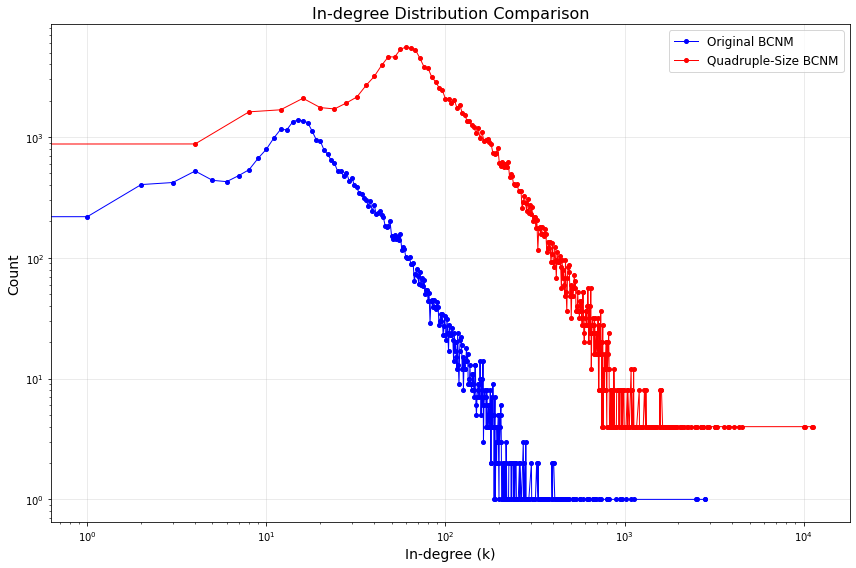

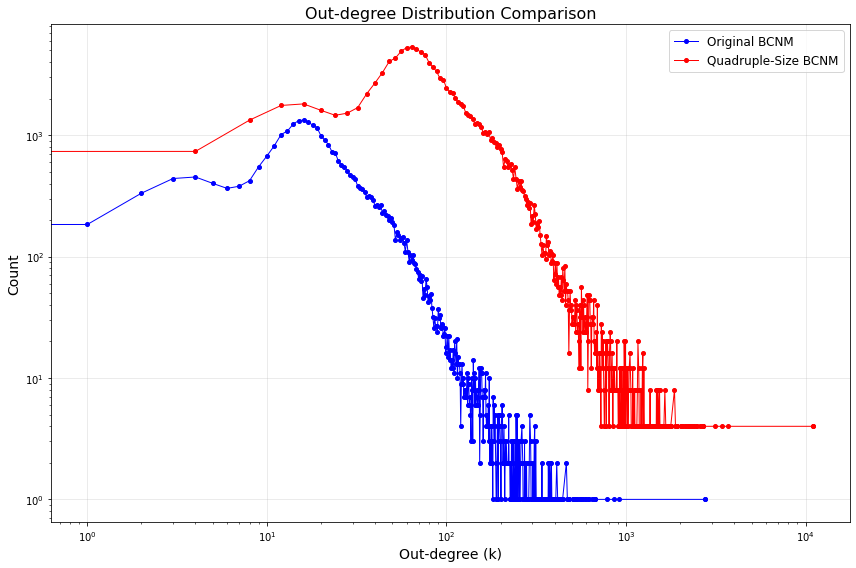

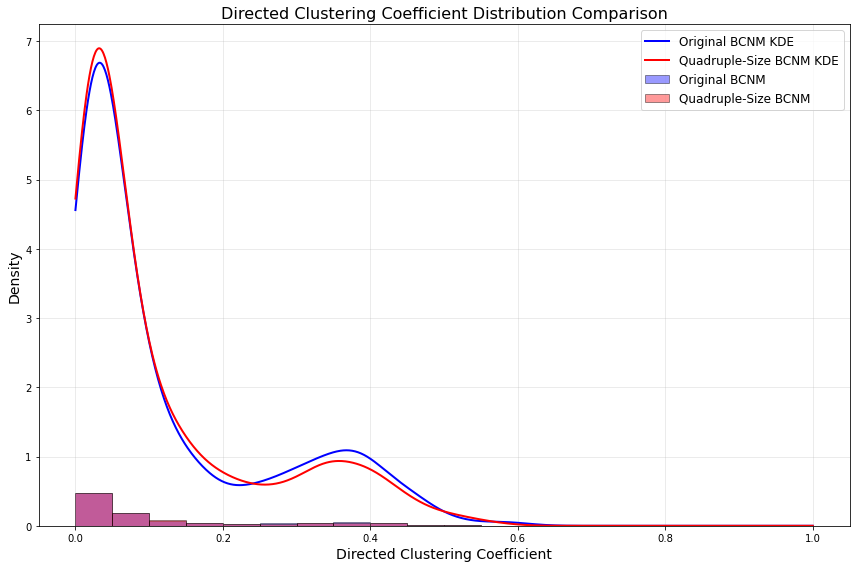

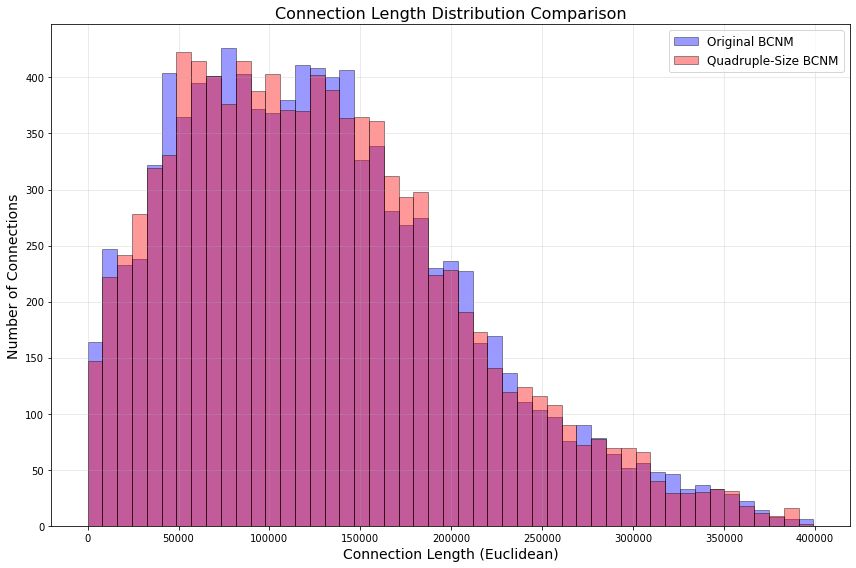

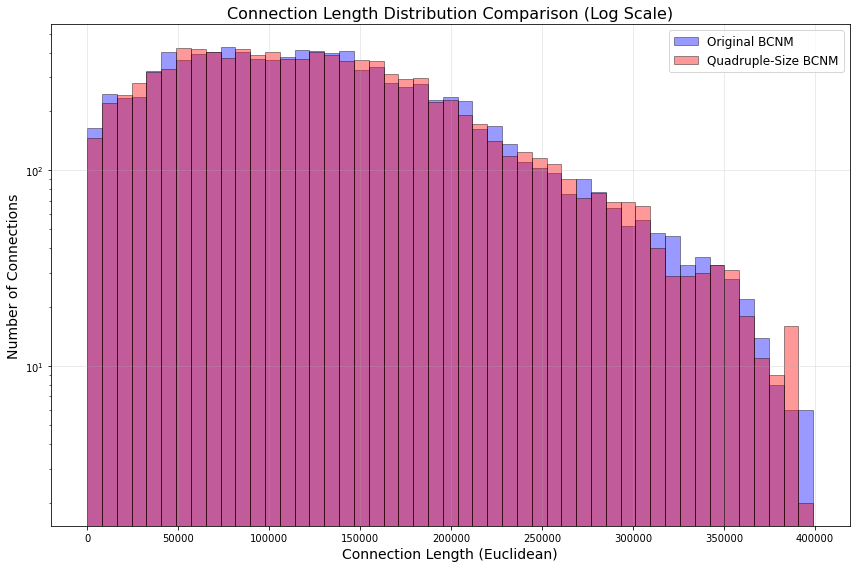

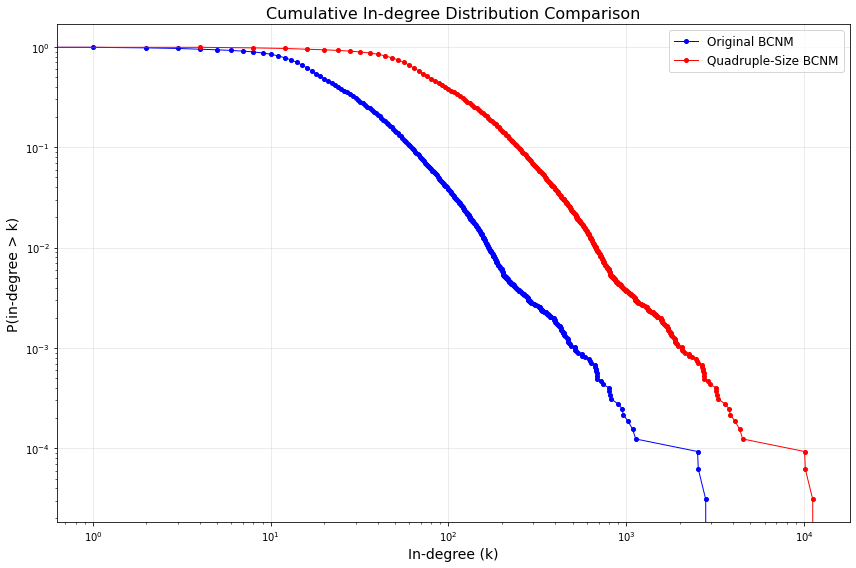

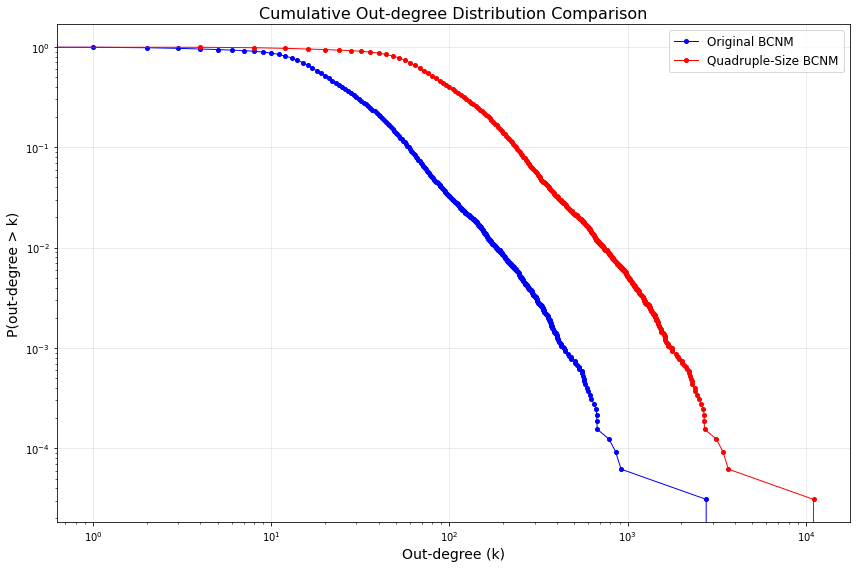

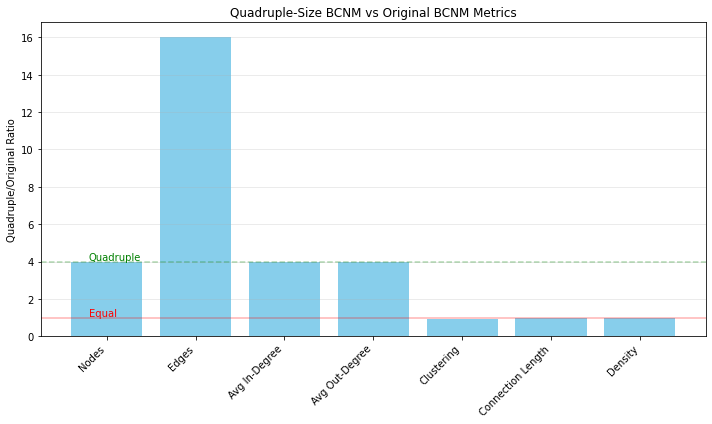

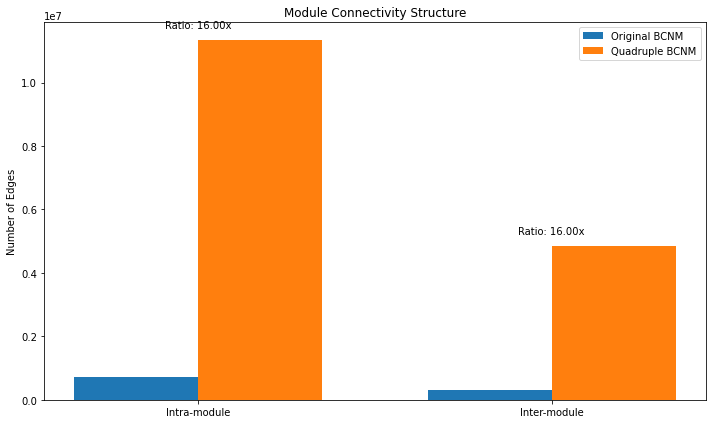

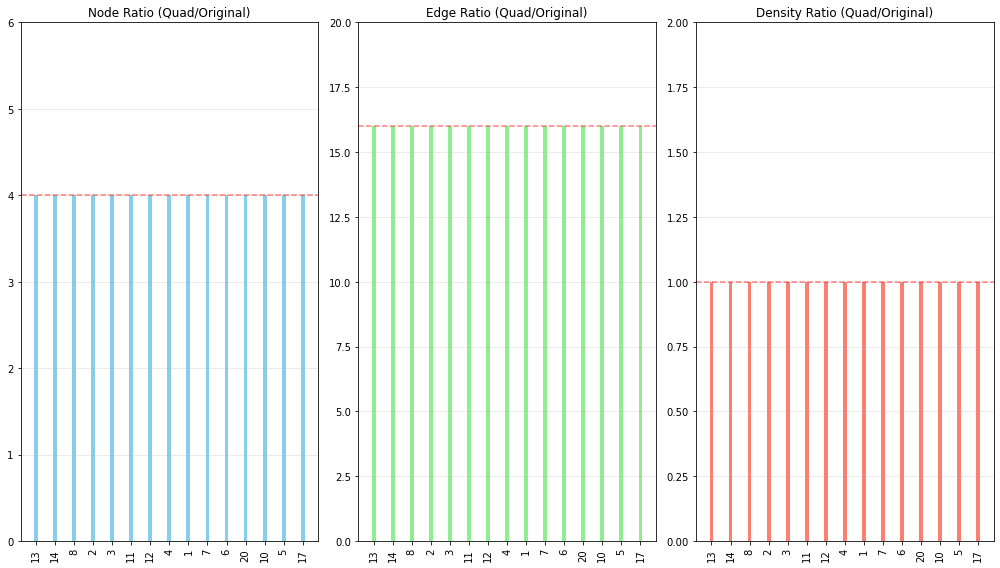

In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting BCNM model quadrupling process...")
start_time = time.time()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created 'plots' directory")

# Load the original BCNM model
print("Loading original BCNM model...")
bcnm_edges_df = pd.read_csv("bcnm_edges.csv")
bcnm_metadata_df = pd.read_csv("bcnm_metadata.csv")
print(f"Loaded {len(bcnm_edges_df)} edges and {len(bcnm_metadata_df)} nodes from BCNM files")

# Create the original BCNM graph
print("Creating original BCNM graph...")
bcnm = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in bcnm_metadata_df.iterrows():
    node_id = node_data['node_id']
    attrs = {}
    for col in bcnm_metadata_df.columns:
        if col != 'node_id':
            attrs[col] = node_data[col]
    bcnm.add_node(node_id, **attrs)

# Add edges
print("Adding edges...")
for _, edge in bcnm_edges_df.iterrows():
    bcnm.add_edge(edge['from'], edge['to'])

print(f"Original BCNM graph: {bcnm.number_of_nodes()} nodes, {bcnm.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(bcnm, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Function for directed clustering coefficient calculation
def directed_clustering_coefficient(G, nodes_to_sample=None):
    """Calculate directed clustering coefficient for nodes in a graph."""
    if nodes_to_sample is None:
        nodes_to_sample = G.nodes()
    
    clustering = {}
    print(f"Processing {len(nodes_to_sample)} nodes for directed clustering...")
    
    for i, node in enumerate(nodes_to_sample):
        if i % 1000 == 0 and i > 0:
            print(f"  Processed {i}/{len(nodes_to_sample)} nodes")
            
        # Get predecessors and successors
        preds = list(G.predecessors(node))
        succs = list(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # For large nodes, sample to improve performance
        if possible_triangles > 1000:
            # Sample predecessor-successor pairs
            sample_size = 1000
            pred_sample = random.sample(preds, min(len(preds), int(np.sqrt(sample_size))))
            succ_sample = random.sample(succs, min(len(succs), int(sample_size / len(pred_sample))))
            
            # Count triangles in sample
            triangles = sum(1 for p in pred_sample for s in succ_sample if G.has_edge(p, s))
            
            # Estimate full count
            actual_triangles = (triangles / (len(pred_sample) * len(succ_sample))) * possible_triangles
        else:
            # Count all triangles
            actual_triangles = sum(1 for p in preds for s in succs if G.has_edge(p, s))
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

# Function to calculate Euclidean distance between nodes
def calculate_euclidean_distance(graph, edge):
    u, v = edge
    try:
        u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
        v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
        return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
    except KeyError:
        return None

# Calculate network metrics for the original BCNM
print("Calculating network metrics for original BCNM...")
in_degrees = dict(bcnm.in_degree())
out_degrees = dict(bcnm.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in bcnm.nodes()}

# Sample nodes for calculating directed clustering coefficient
print("Sampling nodes for clustering coefficient calculation...")
sample_size = min(2000, bcnm.number_of_nodes())
nodes_to_sample = random.sample(list(bcnm.nodes()), sample_size)
bcnm_clustering = directed_clustering_coefficient(bcnm, nodes_to_sample)

print(f"Calculated directed clustering for {len(bcnm_clustering)} nodes")
avg_clustering = sum(bcnm_clustering.values()) / len(bcnm_clustering)
print(f"Original BCNM average directed clustering coefficient: {avg_clustering:.4f}")

# Sample edges for distance calculation
print("Calculating connection lengths for original BCNM (sampled)...")
MAX_DISTANCE_SAMPLES = 10000
edges_to_sample = random.sample(list(bcnm.edges()), min(MAX_DISTANCE_SAMPLES, bcnm.number_of_edges()))
bcnm_distances = []
for edge in edges_to_sample:
    distance = calculate_euclidean_distance(bcnm, edge)
    if distance is not None:
        bcnm_distances.append(distance)
avg_distance = np.mean(bcnm_distances)
print(f"Original BCNM average connection length (sampled): {avg_distance:.4f}")

# Calculate network density
original_density = bcnm.number_of_edges() / (bcnm.number_of_nodes() * (bcnm.number_of_nodes() - 1))
print(f"Original BCNM density: {original_density:.8f}")

##########################
# Create Quadruple-Size BCNM
##########################
print("\nCreating quadruple-size BCNM...")
quad_bcnm = nx.DiGraph()

# Function to generate small random displacement for spatial coordinates
def generate_displacement(scale=0.1):
    return np.random.normal(0, scale, 3)  # For x, y, z coordinates

# First, add all original nodes
print("Adding original nodes to quadruple-size graph...")
for node in bcnm.nodes():
    quad_bcnm.add_node(node, **bcnm.nodes[node])

# Then, create 3 duplicate copies of each node with slight variations
print("Creating 3 duplicate copies of nodes for quadruple-size graph...")
node_to_duplicates = {}  # Mapping from original node to its duplicates

# Create the duplicates
duplicate_count = 0
for node in bcnm.nodes():
    # Generate three new node IDs
    duplicates = []
    for i in range(1, 4):  # Create 3 duplicates (copy 1, 2, and 3)
        new_node = f"dup{i}_{node}"
        
        # Copy attributes with slight spatial variation
        attrs = dict(bcnm.nodes[node])
        if 'x' in attrs and 'y' in attrs and 'z' in attrs:
            # Add small random displacement to coordinates
            displacement = generate_displacement()
            attrs['x'] += displacement[0] * i  # Larger displacement for each copy
            attrs['y'] += displacement[1] * i
            attrs['z'] += displacement[2] * i
        
        # Add the duplicate node
        quad_bcnm.add_node(new_node, **attrs)
        duplicates.append(new_node)
    
    node_to_duplicates[node] = duplicates
    duplicate_count += 1
    
    if duplicate_count % 1000 == 0:
        print(f"  Created {duplicate_count*3} duplicate nodes")

print(f"Created {duplicate_count*3} duplicate nodes (3 copies each)")
print(f"Quadruple-size graph has {quad_bcnm.number_of_nodes()} nodes")

# Add all edges from the original BCNM
print("Adding original edges to quadruple-size graph...")
quad_bcnm.add_edges_from(bcnm.edges())
print(f"Added {bcnm.number_of_edges()} original edges")

# Add edges to connect within each duplicate copy
print("Adding internal edges for each duplicate copy...")
for copy_index in range(3):
    copy_edges = []
    for u, v in bcnm.edges():
        # Get the corresponding nodes in this copy
        dup_u = node_to_duplicates[u][copy_index]
        dup_v = node_to_duplicates[v][copy_index]
        copy_edges.append((dup_u, dup_v))
    
    quad_bcnm.add_edges_from(copy_edges)
    print(f"  Added {len(copy_edges)} edges for duplicate copy {copy_index+1}")

# Now create cross-connections between all copies
print("Creating systematic cross-connections between all copies...")

# We need to create connections between all pairs of copies
# For n copies (including original), there are n(n-1) pairs
# With 4 total copies (original + 3 duplicates), we have 12 pairs

# For tracking progress
total_edges_to_create = bcnm.number_of_edges() * 12  # 12 pairs of copies
edges_created = 0

# Function to get all nodes (original and duplicates)
def get_all_copies(node):
    """Return original node and all its duplicates"""
    return [node] + node_to_duplicates[node]

# Create connections between all pairs of copies
copy_pairs = []
# Original to duplicates
for i in range(3):
    copy_pairs.append((None, i))  # None represents the original
# Between duplicate copies
for i in range(3):
    for j in range(i+1, 3):
        copy_pairs.append((i, j))

for pair_index, (copy1_idx, copy2_idx) in enumerate(copy_pairs):
    cross_edges = []
    
    for u, v in bcnm.edges():
        # Get the corresponding nodes in both copies
        # If copy1_idx is None, it's the original
        u1 = u if copy1_idx is None else node_to_duplicates[u][copy1_idx]
        v1 = v if copy1_idx is None else node_to_duplicates[v][copy1_idx]
        
        u2 = u if copy2_idx is None else node_to_duplicates[u][copy2_idx]
        v2 = v if copy2_idx is None else node_to_duplicates[v][copy2_idx]
        
        # Add cross edges in both directions
        cross_edges.append((u1, v2))
        cross_edges.append((u2, v1))
    
    quad_bcnm.add_edges_from(cross_edges)
    edges_created += len(cross_edges)
    
    copy1_name = "Original" if copy1_idx is None else f"Copy {copy1_idx+1}"
    copy2_name = "Original" if copy2_idx is None else f"Copy {copy2_idx+1}"
    print(f"  Added {len(cross_edges)} cross-connections between {copy1_name} and {copy2_name}")

print(f"Total cross-connections added: {edges_created}")
print(f"Quadruple-size BCNM: {quad_bcnm.number_of_nodes()} nodes, {quad_bcnm.number_of_edges()} edges")

# Calculate network metrics for the quadruple-size BCNM
print("\nCalculating network metrics for quadruple-size BCNM...")
quad_in_degrees = dict(quad_bcnm.in_degree())
quad_out_degrees = dict(quad_bcnm.out_degree())
quad_total_degrees = {node: quad_in_degrees[node] + quad_out_degrees[node] for node in quad_bcnm.nodes()}

# Sample nodes for calculating directed clustering coefficient
print("Sampling nodes for quadruple-size BCNM clustering coefficient calculation...")
quad_sample_size = min(2000, quad_bcnm.number_of_nodes())
quad_nodes_to_sample = random.sample(list(quad_bcnm.nodes()), quad_sample_size)
quad_clustering = directed_clustering_coefficient(quad_bcnm, quad_nodes_to_sample)

print(f"Calculated directed clustering for {len(quad_clustering)} nodes in quadruple-size BCNM")
quad_avg_clustering = sum(quad_clustering.values()) / len(quad_clustering)
print(f"Quadruple-size BCNM average directed clustering coefficient: {quad_avg_clustering:.4f}")

# Sample edges for distance calculation
print("Calculating connection lengths for quadruple-size BCNM (sampled)...")
quad_edges_to_sample = random.sample(list(quad_bcnm.edges()), min(MAX_DISTANCE_SAMPLES, quad_bcnm.number_of_edges()))
quad_distances = []
for edge in quad_edges_to_sample:
    distance = calculate_euclidean_distance(quad_bcnm, edge)
    if distance is not None:
        quad_distances.append(distance)
quad_avg_distance = np.mean(quad_distances)
print(f"Quadruple-size BCNM average connection length (sampled): {quad_avg_distance:.4f}")

# Calculate network density
quad_density = quad_bcnm.number_of_edges() / (quad_bcnm.number_of_nodes() * (quad_bcnm.number_of_nodes() - 1))
print(f"Quadruple-size BCNM density: {quad_density:.8f}")
print(f"Density ratio (Quad/Original): {quad_density/original_density:.4f}")

# Calculate expected edge count for proper density
expected_edge_count = 16 * bcnm.number_of_edges()
print(f"Expected edge count for 1:1 density ratio: {expected_edge_count}")
print(f"Actual edge count: {quad_bcnm.number_of_edges()}, Ratio to original: {quad_bcnm.number_of_edges()/bcnm.number_of_edges():.2f}x")

####################
# Generate plots comparing the original and quadruple-size models
####################
print("\nGenerating comparison plots...")

# Plot in-degree distribution comparison
print("Plotting in-degree distribution...")
plt.figure(figsize=(12, 8))
original_in_degrees = list(dict(bcnm.in_degree()).values())
quad_in_degrees = list(dict(quad_bcnm.in_degree()).values())

plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(quad_in_degrees).keys()), 
           [Counter(quad_in_degrees)[k] for k in sorted(Counter(quad_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Quadruple-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
print("Plotting out-degree distribution...")
plt.figure(figsize=(12, 8))
original_out_degrees = list(dict(bcnm.out_degree()).values())
quad_out_degrees = list(dict(quad_bcnm.out_degree()).values())

plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(quad_out_degrees).keys()), 
           [Counter(quad_out_degrees)[k] for k in sorted(Counter(quad_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Quadruple-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Normalize histograms by scaling counts
orig_weights = np.ones_like(list(bcnm_clustering.values())) / len(bcnm_clustering)
quad_weights = np.ones_like(list(quad_clustering.values())) / len(quad_clustering)

plt.hist(list(bcnm_clustering.values()), bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM', weights=orig_weights)
plt.hist(list(quad_clustering.values()), bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Quadruple-Size BCNM', weights=quad_weights)

# Add kernel density estimation
kde_bcnm = gaussian_kde(list(bcnm_clustering.values()))
kde_quad = gaussian_kde(list(quad_clustering.values()))
x_vals = np.linspace(0, 1, 1000)

plt.plot(x_vals, kde_bcnm(x_vals), 'b-', linewidth=2, label='Original BCNM KDE')
plt.plot(x_vals, kde_quad(x_vals), 'r-', linewidth=2, label='Quadruple-Size BCNM KDE')

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_clustering_coefficient.png', dpi=600)
print("Saved clustering coefficient distribution comparison plot at 600dpi")

# Plot connection length distributions
print("Plotting connection length distributions...")
plt.figure(figsize=(12, 8))
max_distance = max(np.max(bcnm_distances), np.max(quad_distances))
bins = np.linspace(0, max_distance, 50)

plt.hist(bcnm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(quad_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Quadruple-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
print("Plotting connection length distributions with log scale...")
plt.figure(figsize=(12, 8))
plt.hist(bcnm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(quad_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Quadruple-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_connection_length_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot at 600dpi")

# Helper function for cumulative distribution calculation
def compute_cumulative_dist(degrees):
    counter = Counter(degrees)
    sorted_degrees = sorted(counter.items())
    total_nodes = sum(counter.values())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    return x_vals, y_vals

# Calculate cumulative distributions
print("Calculating cumulative degree distributions...")
x_bcnm_in, y_bcnm_in = compute_cumulative_dist(original_in_degrees)
x_quad_in, y_quad_in = compute_cumulative_dist(quad_in_degrees)

# Plot cumulative in-degree distribution
print("Plotting cumulative in-degree distribution...")
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_in, y_bcnm_in, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_quad_in, y_quad_in, 'ro-', markersize=4, linewidth=1, label='Quadruple-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot at 600dpi")

# Calculate out-degree cumulative distributions
x_bcnm_out, y_bcnm_out = compute_cumulative_dist(original_out_degrees)
x_quad_out, y_quad_out = compute_cumulative_dist(quad_out_degrees)

# Plot cumulative out-degree distribution
print("Plotting cumulative out-degree distribution...")
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_out, y_bcnm_out, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_quad_out, y_quad_out, 'ro-', markersize=4, linewidth=1, label='Quadruple-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot at 600dpi")

# Perform statistical tests to compare distributions
print("\nPerforming statistical comparison of distributions...")
# Sample distributions for statistical comparison
def sample_for_stats(data, max_samples=1000):
    if len(data) > max_samples:
        return random.sample(data, max_samples)
    return data

# Get samples for testing
original_in_sample = sample_for_stats(original_in_degrees)
quad_in_sample = sample_for_stats(quad_in_degrees)
original_out_sample = sample_for_stats(original_out_degrees)
quad_out_sample = sample_for_stats(quad_out_degrees)
original_cc_sample = sample_for_stats(list(bcnm_clustering.values()))
quad_cc_sample = sample_for_stats(list(quad_clustering.values()))
original_dist_sample = sample_for_stats(bcnm_distances)
quad_dist_sample = sample_for_stats(quad_distances)

# Perform KS tests
ks_in_degree = ks_2samp(original_in_sample, quad_in_sample)
ks_out_degree = ks_2samp(original_out_sample, quad_out_sample)
ks_clustering = ks_2samp(original_cc_sample, quad_cc_sample)
ks_distances = ks_2samp(original_dist_sample, quad_dist_sample)

print("\nKolmogorov-Smirnov Test Results (Original vs Quadruple-Size):")
print(f"In-degree distributions: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.6f}")
print(f"Out-degree distributions: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.6f}")
print(f"Clustering coefficient distributions: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.6f}")
print(f"Connection length distributions: statistic={ks_distances.statistic:.4f}, p-value={ks_distances.pvalue:.6f}")

# Generate comparison metrics chart
print("\nGenerating metrics comparison chart...")
plt.figure(figsize=(10, 6))
metrics = ['Nodes', 'Edges', 'Avg In-Degree', 'Avg Out-Degree', 'Clustering', 'Connection Length', 'Density']
original_values = [bcnm.number_of_nodes(), bcnm.number_of_edges(), 
                   np.mean(original_in_degrees), np.mean(original_out_degrees),
                   avg_clustering, avg_distance, original_density]
quad_values = [quad_bcnm.number_of_nodes(), quad_bcnm.number_of_edges(),
                np.mean(quad_in_degrees), np.mean(quad_out_degrees),
                quad_avg_clustering, quad_avg_distance, quad_density]

# Normalize by original values
ratio_values = [quad_values[i]/original_values[i] for i in range(len(metrics))]

# Plot the ratios
plt.bar(metrics, ratio_values, color='skyblue')
plt.axhline(y=1.0, color='r', linestyle='-', alpha=0.3)
plt.axhline(y=4.0, color='g', linestyle='--', alpha=0.3)
plt.text(-0.2, 1.05, "Equal", color='r')
plt.text(-0.2, 4.05, "Quadruple", color='g')

plt.ylabel('Quadruple/Original Ratio')
plt.title('Quadruple-Size BCNM vs Original BCNM Metrics')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_metrics_comparison.png', dpi=600)
print("Saved metrics comparison chart at 600dpi")

# Module-by-module comparison
print("\nPerforming module-by-module comparison...")

# Identify common modules in both graphs
original_modules = set(modules.values())
quad_modules = set(nx.get_node_attributes(quad_bcnm, 'module').values())
common_modules = original_modules.intersection(quad_modules)

print(f"Found {len(common_modules)} modules common to both graphs")

# Calculate statistics for each module
module_stats = []
for module in sorted(list(common_modules)):
    print(f"Analyzing module {module}...")
    
    # Get nodes for this module in original graph
    orig_module_nodes = [n for n, m in modules.items() if m == module]
    # Get nodes for this module in quad graph (both original and duplicated)
    quad_module_nodes = [n for n, m in nx.get_node_attributes(quad_bcnm, 'module').items() if m == module]
    
    # Calculate subgraph metrics
    orig_subgraph = bcnm.subgraph(orig_module_nodes)
    quad_subgraph = quad_bcnm.subgraph(quad_module_nodes)
    
    # Node and edge counts
    orig_nodes = orig_subgraph.number_of_nodes()
    quad_nodes = quad_subgraph.number_of_nodes()
    orig_edges = orig_subgraph.number_of_edges()
    quad_edges = quad_subgraph.number_of_edges()
    
    # Average degrees
    if orig_nodes > 0:
        orig_avg_in = np.mean([d for n, d in orig_subgraph.in_degree()])
        orig_avg_out = np.mean([d for n, d in orig_subgraph.out_degree()])
    else:
        orig_avg_in = 0
        orig_avg_out = 0
        
    if quad_nodes > 0:
        quad_avg_in = np.mean([d for n, d in quad_subgraph.in_degree()])
        quad_avg_out = np.mean([d for n, d in quad_subgraph.out_degree()])
    else:
        quad_avg_in = 0
        quad_avg_out = 0
    
    # Calculate directed clustering for samples from this module
    if len(orig_module_nodes) > 10:
        orig_sample = random.sample(orig_module_nodes, min(100, len(orig_module_nodes)))
        orig_cc = directed_clustering_coefficient(bcnm, orig_sample)
        orig_avg_cc = np.mean(list(orig_cc.values())) if orig_cc else 0
    else:
        orig_avg_cc = 0
        
    if len(quad_module_nodes) > 10:
        quad_sample = random.sample(quad_module_nodes, min(100, len(quad_module_nodes)))
        quad_cc = directed_clustering_coefficient(quad_bcnm, quad_sample)
        quad_avg_cc = np.mean(list(quad_cc.values())) if quad_cc else 0
    else:
        quad_avg_cc = 0
    
    # Calculate module density
    if orig_nodes > 1:
        orig_density = orig_edges / (orig_nodes * (orig_nodes - 1))
    else:
        orig_density = 0
        
    if quad_nodes > 1:
        quad_density = quad_edges / (quad_nodes * (quad_nodes - 1))
    else:
        quad_density = 0
    
    # Store statistics
    module_stats.append({
        'module': module,
        'orig_nodes': orig_nodes,
        'quad_nodes': quad_nodes,
        'orig_edges': orig_edges,
        'quad_edges': quad_edges,
        'orig_avg_in': orig_avg_in,
        'quad_avg_in': quad_avg_in,
        'orig_avg_out': orig_avg_out,
        'quad_avg_out': quad_avg_out,
        'orig_avg_cc': orig_avg_cc,
        'quad_avg_cc': quad_avg_cc,
        'orig_density': orig_density,
        'quad_density': quad_density,
        'node_ratio': quad_nodes / max(1, orig_nodes),
        'edge_ratio': quad_edges / max(1, orig_edges),
        'density_ratio': quad_density / max(0.0001, orig_density)
    })
    
    ####################
# Export CSV files
####################
print("\nExporting quadruple-size BCNM model to CSV files...")

# Export edges
print("Exporting edges data...")
quad_edges = list(quad_bcnm.edges())
quad_edges_df = pd.DataFrame(quad_edges, columns=['from', 'to'])
quad_edges_df.to_csv('quad_size_bcnm_edges.csv', index=False)

# Export node metadata
print("Exporting node metadata...")
quad_nodes = []
for node, data in quad_bcnm.nodes(data=True):
    node_data = {
        'node_id': node
    }
    for key, value in data.items():
        node_data[key] = value
    quad_nodes.append(node_data)
quad_metadata_df = pd.DataFrame(quad_nodes)
quad_metadata_df.to_csv('quad_size_bcnm_metadata.csv', index=False)

print("CSV exports completed successfully!")

# Print execution time
end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")
print("Quadruple-size BCNM model generation complete!")# Additional module structure visualization - intra vs inter module connections
print("\nAnalyzing module connectivity structure...")

# Count intra-module vs inter-module edges
def count_module_edges(G):
    modules_attr = nx.get_node_attributes(G, 'module')
    intra_module = 0
    inter_module = 0
    
    for u, v in G.edges():
        if u in modules_attr and v in modules_attr:
            if modules_attr.get(u) == modules_attr.get(v):
                intra_module += 1
            else:
                inter_module += 1
    
    return intra_module, inter_module

orig_intra, orig_inter = count_module_edges(bcnm)
quad_intra, quad_inter = count_module_edges(quad_bcnm)

print(f"Original BCNM: {orig_intra} intra-module edges, {orig_inter} inter-module edges")
print(f"Quadruple BCNM: {quad_intra} intra-module edges, {quad_inter} inter-module edges")
print(f"Intra-module edge ratio: {quad_intra/orig_intra:.3f}")
print(f"Inter-module edge ratio: {quad_inter/orig_inter:.3f}")

# Visualize the intra/inter module edge distribution
plt.figure(figsize=(10, 6))
labels = ['Intra-module', 'Inter-module']
orig_values = [orig_intra, orig_inter]
quad_values = [quad_intra, quad_inter]
ratios = [quad_intra/orig_intra, quad_inter/orig_inter]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, orig_values, width, label='Original BCNM')
plt.bar(x + width/2, quad_values, width, label='Quadruple BCNM')

plt.title('Module Connectivity Structure')
plt.xticks(x, labels)
plt.ylabel('Number of Edges')
plt.legend()

# Add ratio annotations
for i, ratio in enumerate(ratios):
    plt.annotate(f'Ratio: {ratio:.2f}x', 
                 xy=(i, quad_values[i]), 
                 xytext=(0, 10),
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.tight_layout()
plt.savefig('plots/quad_module_connectivity.png', dpi=600)
print("Saved module connectivity structure at 600dpi")# Create a dataframe for better display
module_df = pd.DataFrame(module_stats)

# Print summary statistics
print("\nModule-by-module comparison (top 10 modules by node count):")
top_modules = module_df.sort_values('orig_nodes', ascending=False).head(10)

print(top_modules[['module', 'orig_nodes', 'quad_nodes', 'node_ratio', 
                   'orig_edges', 'quad_edges', 'edge_ratio',
                   'orig_density', 'quad_density', 'density_ratio']].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Calculate average ratios
avg_node_ratio = module_df['node_ratio'].mean()
avg_edge_ratio = module_df['edge_ratio'].mean()
avg_density_ratio = module_df['density_ratio'].mean()

print(f"\nAverage node ratio across modules: {avg_node_ratio:.3f}")
print(f"Average edge ratio across modules: {avg_edge_ratio:.3f}")
print(f"Average density ratio across modules: {avg_density_ratio:.3f}")

# Create module comparison visualization
print("\nGenerating module comparison visualization...")
plt.figure(figsize=(14, 8))

# Select top 15 modules by node count for visualization
vis_modules = module_df.sort_values('orig_nodes', ascending=False).head(15)
x = np.arange(len(vis_modules))
width = 0.2

# Plot node ratios
plt.subplot(1, 3, 1)
plt.bar(x, vis_modules['node_ratio'], width, color='skyblue')
plt.axhline(y=4.0, color='r', linestyle='--', alpha=0.5)
plt.title('Node Ratio (Quad/Original)')
plt.xticks(x, vis_modules['module'], rotation=90)
plt.ylim(0, 6)
plt.grid(axis='y', alpha=0.3)

# Plot edge ratios
plt.subplot(1, 3, 2)
plt.bar(x, vis_modules['edge_ratio'], width, color='lightgreen')
plt.axhline(y=16.0, color='r', linestyle='--', alpha=0.5)
plt.title('Edge Ratio (Quad/Original)')
plt.xticks(x, vis_modules['module'], rotation=90)
plt.ylim(0, 20)
plt.grid(axis='y', alpha=0.3)

# Plot density ratios
plt.subplot(1, 3, 3)
plt.bar(x, vis_modules['density_ratio'], width, color='salmon')
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
plt.title('Density Ratio (Quad/Original)')
plt.xticks(x, vis_modules['module'], rotation=90)
plt.ylim(0, 2)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/quad_module_comparison.png', dpi=600)
print("Saved module comparison visualization at 600dpi")


Generating comparison plots...
Plotting in-degree distribution...
Saved in-degree distribution comparison plot at 600dpi
Plotting out-degree distribution...
Saved out-degree distribution comparison plot at 600dpi
Plotting clustering coefficient distributions...
Saved clustering coefficient distribution comparison plot at 600dpi
Plotting connection length distributions...
Saved connection length distribution comparison plot at 600dpi
Plotting connection length distributions with log scale...
Saved log-scale connection length distribution comparison plot at 600dpi
Calculating cumulative degree distributions...
Plotting cumulative in-degree distribution...
Saved cumulative in-degree distribution comparison plot at 600dpi
Plotting cumulative out-degree distribution...
Saved cumulative out-degree distribution comparison plot at 600dpi

Performing statistical comparison of distributions...

Kolmogorov-Smirnov Test Results (Original vs Quadruple-Size):
In-degree distributions: statistic=0.71

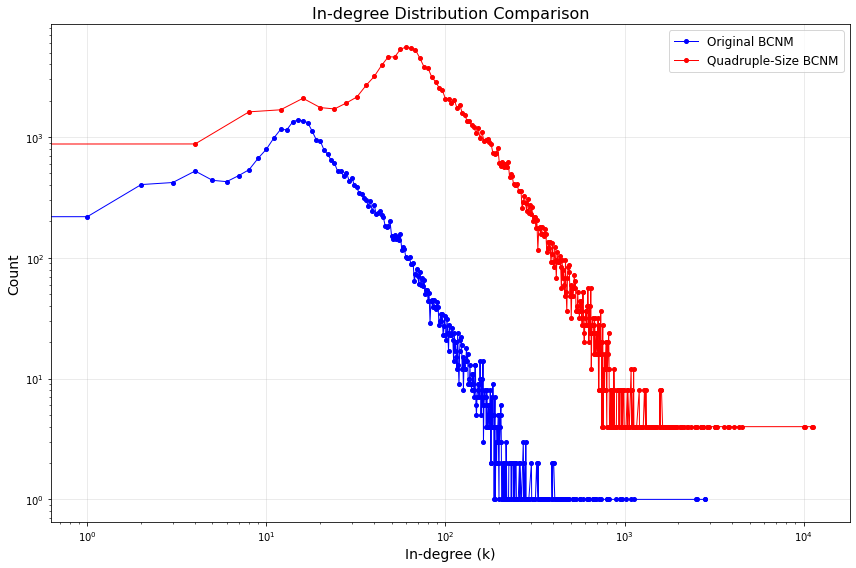

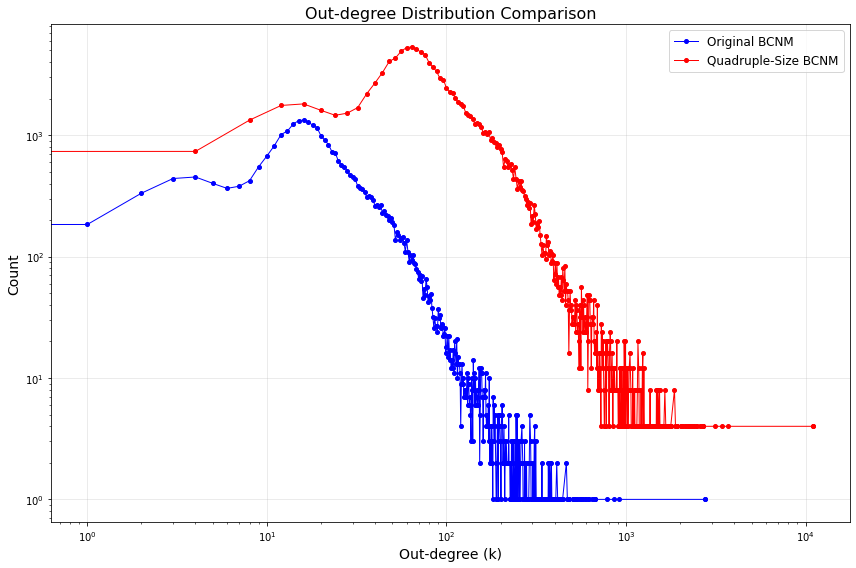

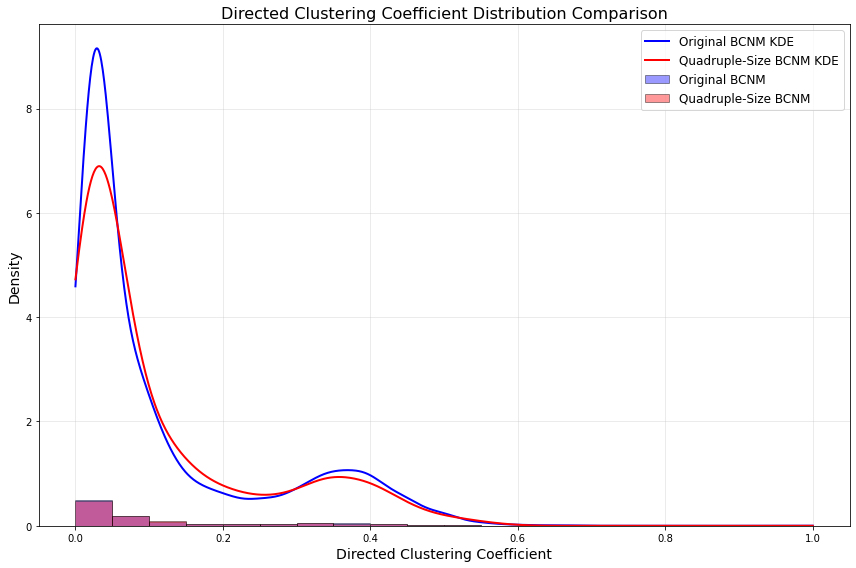

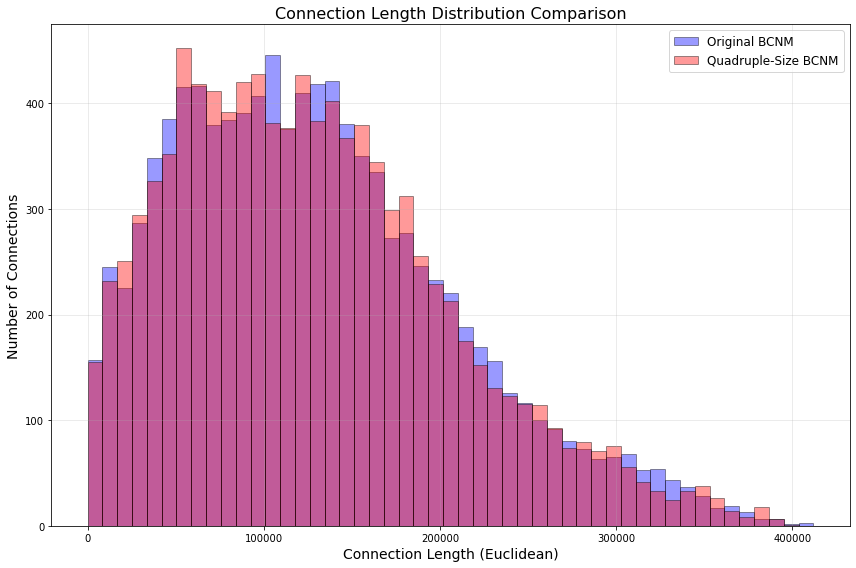

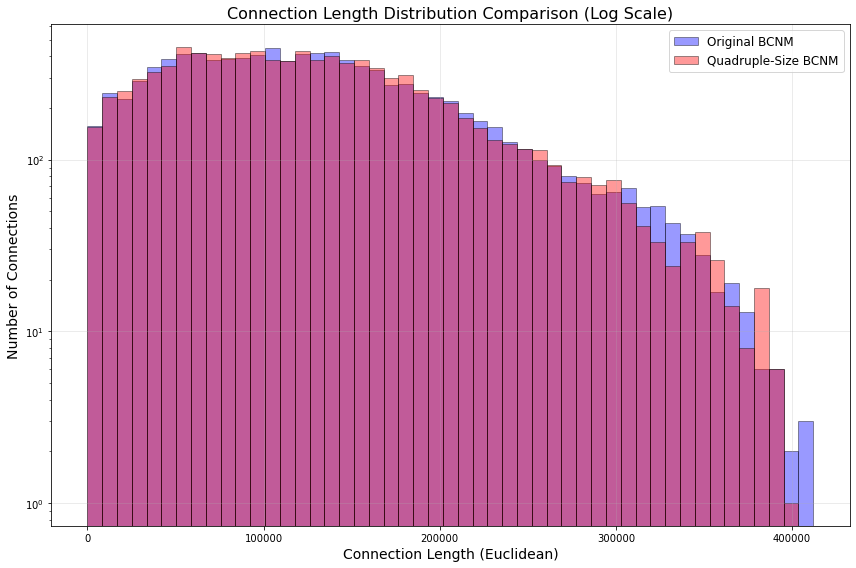

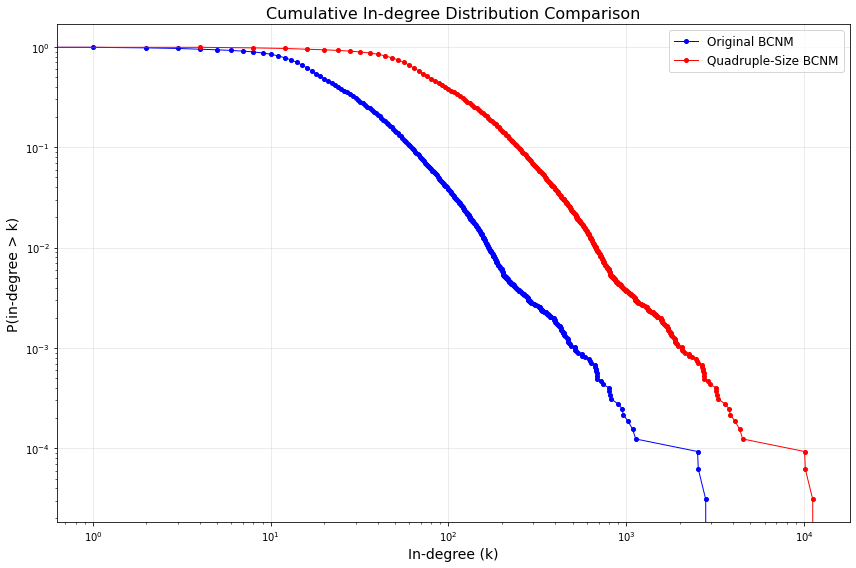

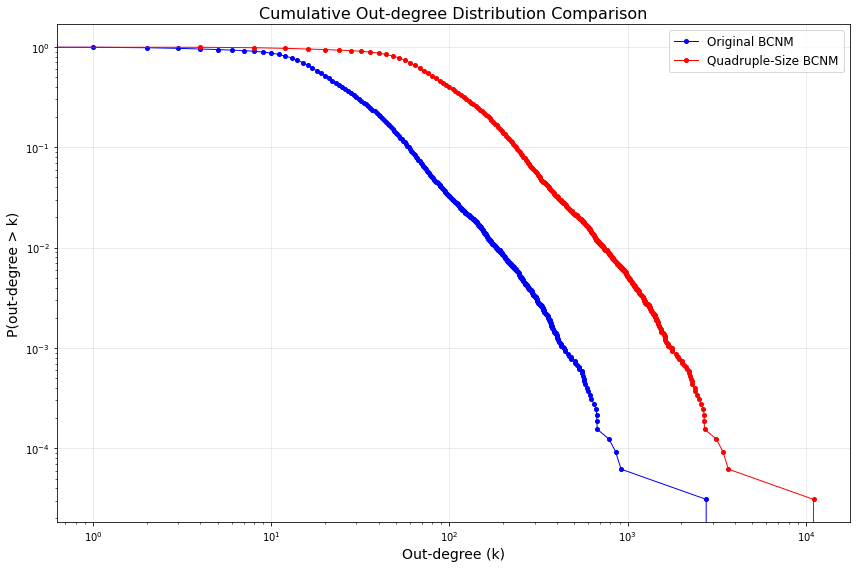

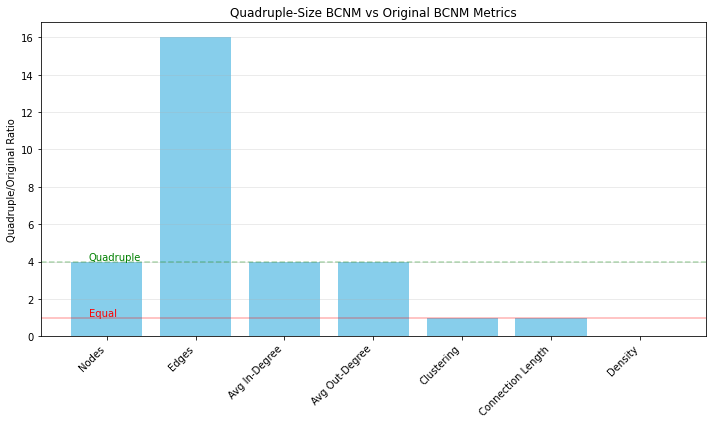

In [9]:
####################
# Generate plots comparing the original and quadruple-size models
####################
print("\nGenerating comparison plots...")

# Plot in-degree distribution comparison
print("Plotting in-degree distribution...")
plt.figure(figsize=(12, 8))
original_in_degrees = list(dict(bcnm.in_degree()).values())
quad_in_degrees = list(dict(quad_bcnm.in_degree()).values())

plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(quad_in_degrees).keys()), 
           [Counter(quad_in_degrees)[k] for k in sorted(Counter(quad_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Quadruple-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
print("Plotting out-degree distribution...")
plt.figure(figsize=(12, 8))
original_out_degrees = list(dict(bcnm.out_degree()).values())
quad_out_degrees = list(dict(quad_bcnm.out_degree()).values())

plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(sorted(Counter(quad_out_degrees).keys()), 
           [Counter(quad_out_degrees)[k] for k in sorted(Counter(quad_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Quadruple-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Normalize histograms by scaling counts
orig_weights = np.ones_like(list(bcnm_clustering.values())) / len(bcnm_clustering)
quad_weights = np.ones_like(list(quad_clustering.values())) / len(quad_clustering)

plt.hist(list(bcnm_clustering.values()), bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM', weights=orig_weights)
plt.hist(list(quad_clustering.values()), bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Quadruple-Size BCNM', weights=quad_weights)

# Add kernel density estimation
kde_bcnm = gaussian_kde(list(bcnm_clustering.values()))
kde_quad = gaussian_kde(list(quad_clustering.values()))
x_vals = np.linspace(0, 1, 1000)

plt.plot(x_vals, kde_bcnm(x_vals), 'b-', linewidth=2, label='Original BCNM KDE')
plt.plot(x_vals, kde_quad(x_vals), 'r-', linewidth=2, label='Quadruple-Size BCNM KDE')

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_clustering_coefficient.png', dpi=600)
print("Saved clustering coefficient distribution comparison plot at 600dpi")

# Plot connection length distributions
print("Plotting connection length distributions...")
plt.figure(figsize=(12, 8))
max_distance = max(np.max(bcnm_distances), np.max(quad_distances))
bins = np.linspace(0, max_distance, 50)

plt.hist(bcnm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(quad_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Quadruple-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
print("Plotting connection length distributions with log scale...")
plt.figure(figsize=(12, 8))
plt.hist(bcnm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='Original BCNM')
plt.hist(quad_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Quadruple-Size BCNM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_connection_length_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot at 600dpi")

# Helper function for cumulative distribution calculation
def compute_cumulative_dist(degrees):
    counter = Counter(degrees)
    sorted_degrees = sorted(counter.items())
    total_nodes = sum(counter.values())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    return x_vals, y_vals

# Calculate cumulative distributions
print("Calculating cumulative degree distributions...")
x_bcnm_in, y_bcnm_in = compute_cumulative_dist(original_in_degrees)
x_quad_in, y_quad_in = compute_cumulative_dist(quad_in_degrees)

# Plot cumulative in-degree distribution
print("Plotting cumulative in-degree distribution...")
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_in, y_bcnm_in, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_quad_in, y_quad_in, 'ro-', markersize=4, linewidth=1, label='Quadruple-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot at 600dpi")

# Calculate out-degree cumulative distributions
x_bcnm_out, y_bcnm_out = compute_cumulative_dist(original_out_degrees)
x_quad_out, y_quad_out = compute_cumulative_dist(quad_out_degrees)

# Plot cumulative out-degree distribution
print("Plotting cumulative out-degree distribution...")
plt.figure(figsize=(12, 8))
plt.loglog(x_bcnm_out, y_bcnm_out, 'bo-', markersize=4, linewidth=1, label='Original BCNM')
plt.loglog(x_quad_out, y_quad_out, 'ro-', markersize=4, linewidth=1, label='Quadruple-Size BCNM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot at 600dpi")

# Perform statistical tests to compare distributions
print("\nPerforming statistical comparison of distributions...")
# Sample distributions for statistical comparison
def sample_for_stats(data, max_samples=1000):
    if len(data) > max_samples:
        return random.sample(data, max_samples)
    return data

# Get samples for testing
original_in_sample = sample_for_stats(original_in_degrees)
quad_in_sample = sample_for_stats(quad_in_degrees)
original_out_sample = sample_for_stats(original_out_degrees)
quad_out_sample = sample_for_stats(quad_out_degrees)
original_cc_sample = sample_for_stats(list(bcnm_clustering.values()))
quad_cc_sample = sample_for_stats(list(quad_clustering.values()))
original_dist_sample = sample_for_stats(bcnm_distances)
quad_dist_sample = sample_for_stats(quad_distances)

# Perform KS tests
ks_in_degree = ks_2samp(original_in_sample, quad_in_sample)
ks_out_degree = ks_2samp(original_out_sample, quad_out_sample)
ks_clustering = ks_2samp(original_cc_sample, quad_cc_sample)
ks_distances = ks_2samp(original_dist_sample, quad_dist_sample)

print("\nKolmogorov-Smirnov Test Results (Original vs Quadruple-Size):")
print(f"In-degree distributions: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.6f}")
print(f"Out-degree distributions: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.6f}")
print(f"Clustering coefficient distributions: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.6f}")
print(f"Connection length distributions: statistic={ks_distances.statistic:.4f}, p-value={ks_distances.pvalue:.6f}")

# Generate comparison metrics chart
print("\nGenerating metrics comparison chart...")
plt.figure(figsize=(10, 6))
metrics = ['Nodes', 'Edges', 'Avg In-Degree', 'Avg Out-Degree', 'Clustering', 'Connection Length', 'Density']
original_values = [bcnm.number_of_nodes(), bcnm.number_of_edges(), 
                   np.mean(original_in_degrees), np.mean(original_out_degrees),
                   avg_clustering, avg_distance, original_density]
quad_values = [quad_bcnm.number_of_nodes(), quad_bcnm.number_of_edges(),
                np.mean(quad_in_degrees), np.mean(quad_out_degrees),
                quad_avg_clustering, quad_avg_distance, quad_density]

# Normalize by original values
ratio_values = [quad_values[i]/original_values[i] for i in range(len(metrics))]

# Plot the ratios
plt.bar(metrics, ratio_values, color='skyblue')
plt.axhline(y=1.0, color='r', linestyle='-', alpha=0.3)
plt.axhline(y=4.0, color='g', linestyle='--', alpha=0.3)
plt.text(-0.2, 1.05, "Equal", color='r')
plt.text(-0.2, 4.05, "Quadruple", color='g')

plt.ylabel('Quadruple/Original Ratio')
plt.title('Quadruple-Size BCNM vs Original BCNM Metrics')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/quad_bcnm_metrics_comparison.png', dpi=600)
print("Saved metrics comparison chart at 600dpi")